### 1. Environment Setup and Library Imports

This section initializes the workspace by importing the necessary libraries for data manipulation, visualization, dimensionality reduction, and deep learning. It also configures the environment settings for consistent output formatting.

##### 1.1. Core Libraries

* **Data Manipulation**: `pandas` and `numpy` for handling structured data.

* **Visualization**: `matplotlib` and `seaborn` for generating statistical plots.

* **Utilities**: `re` (Regular Expressions), `os`, and `warnings` for system and string management.


##### 1.2. Machine Learning & Preprocessing

* **Scikit-Learn**: Used for feature scaling (`StandardScaler`), dimensionality reduction (`PCA`), and dataset splitting.

* **Synthetic Data**: Leveraging `SDV` (Synthetic Data Vault) for metadata management and generating synthetic tabular data using `TVAESynthesizer`.


##### 1.3. Deep Learning Framework (PyTorch)

* Implementation of neural networks using `torch.nn`.

* Optimization and data loading utilities via `DataLoader` and `TensorDataset`.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

from sdv.metadata import SingleTableMetadata
from sdv.single_table import TVAESynthesizer



warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.2f}'.format)


plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')


RAW_PATH      = '../data/weekly_base_bundles_info_202501_202510.csv'

print("The environment is ready.")

The environment is ready.


### 2. Data Loading and Initial Inspection

In this step, the dataset is loaded into the environment. A redundant backup is created immediately to ensure data integrity during the preprocessing phase

* **Data Ingestion**: Reading the raw CSV file from the predefined `RAW_PATH`.

* **Memory Backup**: Creating `df_backup` to allow for easy restoration if destructive transformations are applied.

* **Verification**: Printing the dataset dimensions to confirm the total number of observations and features.



In [2]:
df = pd.read_csv(RAW_PATH)
df_backup = df.copy()  # Backup copy in memory

print(f" Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

 Loaded: 42,377 rows × 15 columns


### 3. Data Cleaning and Filtering

This stage focuses on refining the dataset by removing irrelevant observations, handling missing values, and eliminating redundant features. The goal is to ensure the data aligns with the specific analytical scope of the project.

##### 3.1. Handling Missing Values and Outliers

* **Critical Null Removal**: Dropped rows where essential identifiers (`bundle_id`, `bundle_name`, `bundle_type`) were missing to maintain data quality.

* **Staff Exclusion**: Filtered out records under the `STAFF` category to focus purely on consumer/market data.

##### 3.2. Business Logic Filtering

To narrow the scope to core offerings, the following were removed:

* **Specific Bundle Types**: Excluded `VAS` (Value Added Services) and `FLEXI_BUNDLE`

* **DIY Bundles**: Used string matching to remove "Do It Yourself" (DIY) bundles.

* **Non-Paid Usage**: Removed rows marked as `FREE` usage to concentrate on revenue-generating data.

##### 3.3. Dimensionality Reduction & Deduplication

* **Feature Dropping**: Removed `total_duration` and `usage_type` as they were deemed unnecessary for the subsequent modeling phases.

* **Integrity Check**: Identified and removed duplicate rows to prevent data leakage and bias.



In [3]:

df.dropna(subset=['bundle_id', 'bundle_name', 'bundle_type'], inplace=True)


df = df[df['service_class_category'] != 'STAFF']


df = df[~df['bundle_type'].isin(['VAS', 'FLEXI_BUNDLE'])]

df = df[~df['bundle_name'].str.contains("DIY", case=False, na=False)]

df = df[df['usage_type'] != 'FREE']


df.drop('total_duration', axis=1, inplace=True, errors='ignore')
df.drop('usage_type', axis=1, inplace=True, errors='ignore')

n_duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {n_duplicates}")
df.drop_duplicates(inplace=True)


print(f"Final Size: {df.shape}")
print(f"Removed {42377 - len(df):,} Rows in total")

Duplicate Rows: 0
Final Size: (37667, 13)
Removed 4,710 Rows in total


### 4. Validity Standardization

This section focuses on converting temporal metadata into a numerical format suitable for machine learning models. The primary goal is to transform the inconsistent `validity` strings into a standardized hourly unit.

##### 4.1. Custom Standardization Logic

A robust parsing function, `standardize_validity_to_hours`, was implemented to handle diverse time formats:

* **Extraction**: Uses Regular Expressions (Regex) to isolate numeric values from text.

* **Unit Conversion**:
    
    * ***Months***: Converted to hours based on a 30-day average ($number \times 30 \times 24$).
    * ***Days***: Converted directly ($number \times 24$).
    * ***Hours***: Retained as the base unit.

* **Error Handling**: Manages `NaN` values and strings without numeric data gracefully. 

##### 4.2. Mathematical Transformation

* **Logarithmic Scaling**: Applied `np.log1p` to the cleaned validity hours. This transformation helps normalize skewed data and reduces the impact of extreme outliers (e.g., comparing a 1-hour validity to a 720-hour monthly validity).

##### 4.3. Final Cleanup and Validation

* **Null Removal**: Dropped any records that failed the conversion process to ensure a clean dataset for modeling.

* **Index Reset**: Re-indexed the DataFrame to maintain a continuous sequence after row removal.

* **Integrity Verification**: Confirmed a zero-null count for the new features.




In [4]:
def standardize_validity_to_hours(text):
    if pd.isna(text) or str(text).strip().lower() == 'nan':
        return np.nan
    
    text = str(text).lower()
    
    
    match = re.search(r'\d+(\.\d+)?', text)
    if not match:
        return np.nan 
        
    number = float(match.group())
    
    
    if 'month' in text:
        return number * 30.0 * 24.0  
    elif 'day' in text:
        return number * 24.0        
    elif 'hour' in text:
        return number                
    else:
        
        return number


df['validity_hours_clean'] = df['validity'].apply(standardize_validity_to_hours)


df['validity_hours_log'] = np.log1p(df['validity_hours_clean'])

print("Validity has been converted to hours and processed logarithmically.")
display(df[['validity', 'validity_hours_clean', 'validity_hours_log']].head(5))

Validity has been converted to hours and processed logarithmically.


,validity,validity_hours_clean,validity_hours_log
0,30 Day(s),720.00,6.58
1,30 Day(s),720.00,6.58
2,30 Day(s),720.00,6.58
3,1 Day(s),24.00,3.22
4,30 Day(s),720.00,6.58


In [5]:
df[['validity_hours_clean', 'validity_hours_log']].isnull().sum()

validity_hours_clean    56
validity_hours_log      56
dtype: int64

In [6]:

df.dropna(subset=['validity', 'validity_hours_clean', 'validity_hours_log'], inplace=True)


df.reset_index(drop=True, inplace=True)


print(f"Missing records removed successfully.")
print(f"Remaining record count: {len(df):,}")
print(f"Missing values in validity columns now:\n{df[['validity_hours_clean', 'validity_hours_log']].isnull().sum()}")

Missing records removed successfully.
Remaining record count: 37,611
Missing values in validity columns now:
validity_hours_clean    0
validity_hours_log      0
dtype: int64


### 5.  Price Extraction and Normalization

This section addresses missing and inconsistent financial data. Since price is a critical signal for Variational Autoencoders (VAE), a multi-step approach is used to maximize data recovery and ensure numerical stability.

##### 5.1. Heuristic Price Recovery

A significant portion of missing price values is recovered from the bundle_name strings using a custom extraction logic:

* **Regex Extraction**: The function `extract_price` targets patterns like `@1000 F` to capture the price directly from the product name.

* **Intelligent Filling**: These extracted values are used to fill holes in the primary `price` column, salvaging records that would otherwise be dropped.

##### 5.2. Advanced Price Cleaning

The `clean_price_final function` provides robust parsing to handle varied formatting:

* **Symbol Removal**: Strips currency markers and whitespace.

* **Decimal Standardization**: Corrects regional variations in comma/period usage (e.g., converting `1.000` or `1,00` to a standard float).

* **Validation**: Ensures only valid numerical representations remain in the `price_clean` feature.

##### 5.3. Logarithmic Scaling

* **Distribution Adjustment**: Just like the validity feature, `price_clean_log` is created using `np.log1p`.

* **Model Readiness**: This transformation reduces the variance of high-priced bundles, preventing them from dominating the loss function during neural network training.


In [ ]:


def extract_price(text):
    """ Extracts price from bundle name using regex """
    if pd.isna(text):
        return None
    match = re.search(r'@(\d+)\s*F', str(text))
    if match:
        return float(match.group(1))
    return None

def clean_price_final(value):
    """
    Cleans price column from currency symbols, spaces, and handles formatting.
    Targeted for VAE where preserving high-value signal is critical.
    """
    if pd.isna(value):
        return np.nan
    
    cleaned = re.sub(r'[^\d.,]', '', str(value))
    
    if ',' in cleaned and '.' in cleaned:
        cleaned = cleaned.replace(',', '')
    elif ',' in cleaned:
        cleaned = cleaned.replace(',', '.')
        
    try:
        return float(cleaned)
    except ValueError:
        return np.nan



print("Start processing prices...")


mask_missing_price = df['price'].isna()


extracted_prices = df.loc[mask_missing_price, 'bundle_name'].apply(extract_price)


filled_from_bundle = extracted_prices.notna().sum()


df['price'] = df['price'].fillna(extracted_prices)

print(f"Successfully extracted and filled [{filled_from_bundle:,.0f}] missing values from (bundle_name).")


print("Cleaning price column...")
df['price_clean'] = df['price'].apply(clean_price_final)


df.dropna(subset=['price_clean'], inplace=True)
print(f"Price cleaning complete.")



df['price_clean_log'] = np.log1p(df['price_clean'])


display(df[['price', 'bundle_name', 'price_clean', 'price_clean_log']].head(10))
df[['price_clean']].info()

Start processing prices...
Successfully extracted and filled [18] missing values from (bundle_name).
Cleaning price column...
Price cleaning complete.


,price,bundle_name,price_clean,price_clean_log
0,4000,Forfait 1.6Go 30 jours@4000F,4000.00,8.29
1,690,Forfait appels RCA 2 mins 30 jours@690F,690.00,6.54
2,200,Forfait appels Nigeria 2 mins 30 jours@200F,200.00,5.30
3,215,Forfait 1 jour 170MB@215F,215.00,5.38
4,50050,NDAKO BOX ILLIMITE@50050F,50050.00,10.82
5,1500,Int Bundle ROW 10min 30jours a 1500F,1500.00,7.31
6,590,Forfait appels Guinee Conakry 2 mins 30 jours@590F,590.00,6.38
7,185,Ndeko_11Mins 1 jour@185F,185.00,5.23
8,122,SMS Bundle 3 Days@122F,122.00,4.81
9,50,Promo Back2School 250MB 2 Days @50F,50.00,3.93


<class 'pandas.core.frame.DataFrame'>
Index: 37608 entries, 0 to 37610
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price_clean  37608 non-null  float64
dtypes: float64(1)
memory usage: 587.6 KB


### 6. Advanced Volume Extraction & Feature Recovery

This section implements a complex heuristic engine to recover missing values in the `configured_volume` column. By parsing strings within the `bundle_name`, we can reconstruct the service capacity (Data, Voice, or SMS) that was otherwise missing.


##### 6.1. Mapping and Pattern Logic

To handle diverse naming conventions, the extraction engine uses several mapping layers:

* **Type Mapping**: Standardizes various bundle type strings into core categories: `VOICE`, `SMS`,or `DATA`.

* **Regex Pattern Matching**: A comprehensive dictionary of Regular Expressions identifies units like `GB/MB` for data, `min/mn` for voice, and `sms/msg` for messaging.

* **Unlimited Detection**: Specific checks for terms like `illimité` or `unlimited` to flag non-metered bundles.

##### 6.2. Complex Voice Parsing

A specialized function, `_parse_complex_voice`, handles intricate voice bundle formats:

* **Time Aggregation**: Sums multiple time values found in a single string (e.g., "10 min + 30 sec").

* **Slash Formats**: Correctly parses aggregate values such as "130/15 mn" by summing the components.

* **Unit Conversion**: Automatically converts seconds into decimal minutes to maintain numerical consistency.

##### 6.3. Priority-Based Extraction for Mixed Bundles

For `MIXED` bundles, the engine follows a strict hierarchy (`DATA` > `VOICE` > `SMS`) to determine the primary volume metric if multiple are present, ensuring the most significant feature is captured first.


##### 6.4. Execution and Audit

* **Tracking**: A new feature, `volume_fill_source`, is created to track whether a value was "original," "extracted," or "not_found."

* **Efficiency**: The loop targets only rows with missing values, significantly improving processing speed.

* **Validation**: Samples of both successfully filled and remaining missing records are displayed to audit the accuracy of the regex logic.



In [ ]:


TYPE_MAP = {
    'BUNDLE_VOICE': 'VOICE',
    'BUNDLE_SMS':   'SMS',
    'BUNDLE_DATA':  'DATA',   
}



patterns = {
    'DATA': [
        r'(\d[\d,.]*)\s*gb',
        r'(\d[\d,.]*)\s*go',
        r'(\d[\d,.]*)\s*mb',
        r'(\d[\d,.]*)\s*mo',
    ],
    'VOICE': [
        r'(\d[\d,.]*)\s*mn',
        r'(\d[\d,.]*)\s*min',
        r'(\d[\d,.]*)\s*mins',
        r'(\d[\d,.]*)\s*appel',
        r'(\d[\d,.]*)\s*voc',
    ],
    'SMS': [
        r'(\d[\d,.]*)\s*sms',
        r'(\d[\d,.]*)\s*msg',
    ],
}


MIXED_ORDER = ['DATA', 'VOICE', 'SMS']

unlimited_patterns = [
    r'illimit', r'unlimit', r'illimité', r'unlimité',
    r'illimitée', r'unlimitée', r'infini',
]

UNIT_MAP = {
    'DATA': {
        r'(\d[\d,.]*)\s*gb': 'GB',
        r'(\d[\d,.]*)\s*go': 'GB',
        r'(\d[\d,.]*)\s*mb': 'MB',
        r'(\d[\d,.]*)\s*mo': 'MB',
    },
    'VOICE': {
        r'(\d[\d,.]*)\s*mn':    'min',
        r'(\d[\d,.]*)\s*min':   'min',
        r'(\d[\d,.]*)\s*mins':  'min',
        r'(\d[\d,.]*)\s*appel': 'appel',
        r'(\d[\d,.]*)\s*voc':   'voc',
    },
    'SMS': {
        r'(\d[\d,.]*)\s*sms': 'SMS',
        r'(\d[\d,.]*)\s*msg': 'msg',
    },
}




_VOICE_UNITS_RE = re.compile(r'(\d[\d,.]*)\s*(mins?|mn|sec|s)', re.IGNORECASE)

def _parse_complex_voice(text):
    """
    Finds all occurrences of minutes and seconds, sums them up, 
    and converts seconds to decimal minutes.
    Now specifically handles slash formats like '130/15 mn'.
    """
    total_minutes = 0.0
    matched = False
    
    
    slash_match = re.search(r'(\d[\d,.]*)\s*/\s*(\d[\d,.]*)\s*(mins?|mn)', text, re.IGNORECASE)
    if slash_match:
        val1 = float(slash_match.group(1).replace(',', '.'))
        val2 = float(slash_match.group(2).replace(',', '.'))
        total_minutes += (val1 + val2)
        matched = True
        
        text = text.replace(slash_match.group(0), '')

    
    hits = _VOICE_UNITS_RE.findall(text)
    if hits:
        matched = True
        for val, unit in hits:
            num = float(val.replace(',', '.'))
            if unit.lower() in ['sec', 's']:
                total_minutes += num / 60  
            else:
                total_minutes += num

    
    if not matched:
        return None

    
    if total_minutes == int(total_minutes):
        return f"{int(total_minutes)}min"
    else:
        return f"{round(total_minutes, 2)}min"


def _search_type(name_lower, btype):
    """Search for the first matching pattern for the bundle type and return value with unit."""
    for pat in patterns.get(btype, []):
        m = re.search(pat, name_lower, re.IGNORECASE)
        if m:
            raw = m.group(1).replace(',', '.')
            unit = UNIT_MAP.get(btype, {}).get(pat, '')
            return f"{raw}{unit}"
    return None



def extract_volume_from_name(bundle_name, bundle_type):
    name_lower = str(bundle_name).lower()
    raw_type   = str(bundle_type).upper().strip()
    btype      = TYPE_MAP.get(raw_type, raw_type)  

    
    for pat in unlimited_patterns:
        if re.search(pat, name_lower, re.IGNORECASE):
            return 'Unlimited'

   
    if btype in ('VOICE', 'MIXED'):
        complex_result = _parse_complex_voice(bundle_name)
        if complex_result:
            return complex_result

    
    if btype == 'MIXED':
        for t in MIXED_ORDER:
            result = _search_type(name_lower, t)
            if result:
                return result
        return None

    
    return _search_type(name_lower, btype)



missing_mask = df['configured_volume'].isna()
print(f"Missing values before processing : {missing_mask.sum()}")


if 'volume_fill_source' not in df.columns:
    df['volume_fill_source'] = 'original'

for idx in df.index[missing_mask]:
    bundle_name = str(df.at[idx, 'bundle_name'])
    bundle_type = str(df.at[idx, 'bundle_type'])
    extracted   = extract_volume_from_name(bundle_name, bundle_type)
    
    if extracted is not None:
        df.at[idx, 'configured_volume'] = extracted
        df.at[idx, 'volume_fill_source'] = 'extracted_from_name'
    else:
        df.at[idx, 'volume_fill_source'] = 'not_found'

still_missing = df['configured_volume'].isna().sum()
filled        = missing_mask.sum() - still_missing

print(f"Successfully filled              : {filled}")
print(f"Still missing (not_found)        : {still_missing}")



print("\nSample of rows that were filled:")
display(df[df['volume_fill_source'] == 'extracted_from_name'][
    ['bundle_name', 'bundle_type', 'configured_volume']
].drop_duplicates('bundle_name').head(25))

print("\nSample of rows that were NOT filled:")
display(df[df['volume_fill_source'] == 'not_found'][
    ['bundle_name', 'bundle_type', 'configured_volume']
].drop_duplicates('bundle_name').head(20))

Missing values before processing : 3077
Successfully filled              : 2020
Still missing (not_found)        : 1057

Sample of rows that were filled:


,bundle_name,bundle_type,configured_volume
32,Forfait EBU 1050 SMS 30 Jours@1100F,BUNDLE_SMS,1050SMS
40,Forfait tous reseaux 67 mins 7 jour@3000F,BUNDLE_VOICE,67min
61,Basic -330 mn - 4950F,BUNDLE_VOICE,330min
83,Forfait tous reseaux 456 mins 30 jour@20500F,BUNDLE_VOICE,456min
99,Forfait MagicVoice 30 jours 318 mins @3500F,BUNDLE_VOICE,318min
113,Forfait appels 5 mins 1 jour@15F,BUNDLE_VOICE,5min
130,Forfait tous reseaux 10 mins 1 jour@450F + BONUS,BUNDLE_VOICE,10min
150,Forfait appels 5 mins 1 jour@25F,BUNDLE_VOICE,5min
153,Illimite 2H par jour pendant 30 Jours@5500F,BUNDLE_DATA,Unlimited
160,Forfait tous reseaux 2 mins 1 jour@100F + BONUS,BUNDLE_VOICE,2min



Sample of rows that were NOT filled:


,bundle_name,bundle_type,configured_volume
8,SMS Bundle 3 Days@122F,BUNDLE_SMS,NaN
20,SMS Bundle 1 Day @26F,BUNDLE_SMS,NaN
87,SMS Bundle 1 Day @41F,BUNDLE_SMS,NaN
105,SMS Bundle 10 Days@507F,BUNDLE_SMS,NaN
176,SMS Bundle 1 day@15F,BUNDLE_SMS,NaN
191,SMS Bundle 5 Days@335F,BUNDLE_SMS,NaN
229,SMS Bundle 2 Days @66F,BUNDLE_SMS,NaN
308,PRO GFU 10-23750F,BUNDLE_VOICE,NaN
589,SMS Bundle 1 day@50F,BUNDLE_SMS,NaN
615,SMS Bundle 3 Days@100F,BUNDLE_SMS,NaN


In [9]:


not_found_df = df[df['volume_fill_source'] == 'not_found'][
    ['bundle_name', 'bundle_type', 'configured_volume']
].copy()

print(f"Total unfilled rows: {len(not_found_df)}")
print("\n" + "="*60)


print("\nbundle_type distribution for unfilled values:")
print(not_found_df['bundle_type'].value_counts())

print("\n" + "="*60)


for btype in not_found_df['bundle_type'].unique():
    sample = not_found_df[not_found_df['bundle_type'] == btype]['bundle_name'].unique()[:15]
    print(f"\n[{btype}] — Sample bundle names:")
    for name in sample:
        print(f"    {name}")

print("\n" + "="*60)


print("\nTop 20 most frequent bundle_names in unfilled rows:")
print(not_found_df['bundle_name'].value_counts().head(20))

Total unfilled rows: 1057


bundle_type distribution for unfilled values:
bundle_type
BUNDLE_SMS      881
BUNDLE_VOICE    171
BUNDLE_DATA       5
Name: count, dtype: int64


[BUNDLE_SMS] — Sample bundle names:
    SMS Bundle 3 Days@122F
    SMS Bundle 1 Day @26F 
    SMS Bundle 1 Day @41F 
    SMS Bundle 10 Days@507F
    SMS Bundle 1 day@15F
    SMS Bundle 5 Days@335F
    SMS Bundle 2 Days @66F 
    SMS Bundle 1 day@50F
    SMS Bundle 3 Days@100F

[BUNDLE_VOICE] — Sample bundle names:
    PRO GFU 10-23750F
    PRO GFU 20-46000F
    PRO GFU 30-67500F
    PRO GFU 15-35250F
    PRO GFU 5-12000F

[BUNDLE_DATA] — Sample bundle names:
    Whatsapp text 1 jour@50F
    Whatsapp text 1 jour@10F 


Top 20 most frequent bundle_names in unfilled rows:
bundle_name
SMS Bundle 3 Days@122F       187
SMS Bundle 5 Days@335F       150
SMS Bundle 1 Day @26F        104
SMS Bundle 2 Days @66F       103
SMS Bundle 10 Days@507F      102
SMS Bundle 1 Day @41F        102
SMS Bundle 1 day@50F          45
SMS Bun

### 7. Multi-Modal Volume Parsing and Unit Conversion

This section implements a sophisticated parsing engine to decompose the `configured_volume` into distinct, model-ready numerical features. It handles the transition from heterogeneous text strings to a structured format across three primary dimensions: Data, Voice, and SMS.

##### 7.1. Logic for Feature Decomposition

The `parse_volumes` function serves as the core logic for this transformation:

* **Unlimited Handling**: Identifies "unlimited" keywords and flags them using an `is_unlimited_volume` binary indicator.

* **Compound Voice Extraction**: Uses regex to capture complex durations (e.g., minutes and seconds) and converts them into decimal minutes.

* **Unit Standardization**:

    * Data: Converts all variations of GB/GO to MB ($Value \times 1024$).
    * Voice: Standardizes all time markers to Minutes.
    * SMS: Extracts the integer count of messages.

* **Intelligent Inference**: If a unit is missing in the volume string, the engine cross-references the `bundle_name` and `bundle_type` to infer the correct metric.

##### 7.2. Quantitative Imputation for Unlimited Bundles

To ensure compatibility with neural networks (which cannot process "infinity"), unlimited values are represented using **Quantile Imputation**:

* Values flagged as `-1.0 `(unlimited) are replaced by the 95th percentile ($Q_{95}$) of their respective category.

* This approach maintains the high-value signal of an unlimited bundle without introducing extreme outliers that could destabilize the model's loss function.

##### 7.3. Feature Integration

The result is a set of four new distinct features:

  * `volume_MB`: Continuous numerical value for data capacity.

  * `volume_min`: Continuous numerical value for voice duration.

  * `volume_SMS`: Discrete count for messaging capacity.
  
  * `is_unlimited_volume`: Boolean flag preserving the "unlimited" status.

  

In [10]:

_NAME_DATA_PATTERNS = [
    (r'(\d[\d,.]*)\s*gb', 'GB'),
    (r'(\d[\d,.]*)\s*go', 'GB'),
    (r'(\d[\d,.]*)\s*mb', 'MB'),
    (r'(\d[\d,.]*)\s*mo', 'MB'),
]

TYPE_MAP = {
    'BUNDLE_VOICE': 'VOICE',
    'BUNDLE_SMS':   'SMS',
    'BUNDLE_DATA':  'DATA',
}

_VOICE_COMPOUND_RE = re.compile(
    r'(\d[\d,.]*)\s*(?:mins?|mn)[^,]*?(\d[\d,.]*)\s*(?:sec|s)\b',
    re.IGNORECASE
)

def _unit_from_name(bundle_name):
    """Infers the unit from the bundle name if not explicitly stated"""
    name_lower = str(bundle_name).lower()
    for pat, unit in _NAME_DATA_PATTERNS:
        if re.search(pat, name_lower, re.IGNORECASE):
            return unit
    return 'MB'  

def parse_volumes(row):
    """
    Parses volume and returns 4 values: 
    (MB volume, Minutes volume, SMS volume, Unlimited indicator)
    """
    volume_str = row['configured_volume']
    bundle_type = row['bundle_type']
    bundle_name = row['bundle_name']
    
   
    vol_MB, vol_min, vol_SMS = 0.0, 0.0, 0.0
    is_unlimited = 0
    
    if pd.isna(volume_str):
        return np.nan, np.nan, np.nan, 0

    v = str(volume_str).strip().lower()
    btype = TYPE_MAP.get(str(bundle_type).upper().strip(), str(bundle_type).upper().strip())

    
    if v in ('unlimited', 'illimité', 'illimitée', 'unlimitée', 'infini'):
        is_unlimited = 1
        
        if btype == 'VOICE':
            vol_min = -1.0
        elif btype == 'SMS':
            vol_SMS = -1.0
        elif btype == 'DATA':
            vol_MB = -1.0
        else:
            # Try to infer from name if type is unclear
            name_lower = str(bundle_name).lower()
            if 'sms' in name_lower: vol_SMS = -1.0
            elif 'voix' in name_lower or 'min' in name_lower: vol_min = -1.0
            else: vol_MB = -1.0
            
        return vol_MB, vol_min, vol_SMS, is_unlimited

    
    compound = _VOICE_COMPOUND_RE.search(v)
    if compound:
        mins = float(compound.group(1).replace(',', '.'))
        secs = float(compound.group(2).replace(',', '.'))
        vol_min = round(mins + secs / 60, 4)
        return vol_MB, vol_min, vol_SMS, is_unlimited

    
    m = re.search(r'(\d[\d,.]*)\s*([a-zA-Z]*)', v.replace('\xa0', ' '))
    if not m:
        return np.nan, np.nan, np.nan, is_unlimited

    num_str = m.group(1).replace(' ', '').replace(',', '.')
    unit_str = m.group(2).strip().lower()

    try:
        num = float(num_str)
    except ValueError:
        return np.nan, np.nan, np.nan, is_unlimited

    
    actual_unit = unit_str.upper()
    if actual_unit in ('GB', 'GO', 'G'):
        vol_MB = round(num * 1024, 4)
    elif actual_unit in ('MB', 'MO'):
        vol_MB = num
    elif actual_unit in ('MIN', 'MINS', 'MN'):
        vol_min = num
    elif actual_unit == 'SMS':
        vol_SMS = int(num)
    elif actual_unit == '':
        # If unit is missing, rely on bundle type
        if btype == 'VOICE': vol_min = num
        elif btype == 'SMS': vol_SMS = int(num)
        else: 
            inferred = _unit_from_name(bundle_name)
            if inferred == 'GB': vol_MB = round(num * 1024, 4)
            elif inferred == 'MB': vol_MB = num
            else: vol_MB = num
    else:
        vol_MB = num # Default

    return vol_MB, vol_min, vol_SMS, is_unlimited




parsed_columns = df.apply(parse_volumes, axis=1, result_type='expand')
parsed_columns.columns = ['volume_MB', 'volume_min', 'volume_SMS', 'is_unlimited_volume']


df = pd.concat([df, parsed_columns], axis=1)




q95_MB = df.loc[df['volume_MB'] > 0, 'volume_MB'].quantile(0.95)
q95_min = df.loc[df['volume_min'] > 0, 'volume_min'].quantile(0.95)
q95_SMS = df.loc[df['volume_SMS'] > 0, 'volume_SMS'].quantile(0.95)


q95_MB = q95_MB if pd.notna(q95_MB) else 999999
q95_min = q95_min if pd.notna(q95_min) else 999999
q95_SMS = q95_SMS if pd.notna(q95_SMS) else 999999


df.loc[df['volume_MB'] == -1.0, 'volume_MB'] = q95_MB
df.loc[df['volume_min'] == -1.0, 'volume_min'] = q95_min
df.loc[df['volume_SMS'] == -1.0, 'volume_SMS'] = q95_SMS



display_cols = ['bundle_type', 'configured_volume', 'volume_MB', 'volume_min', 'volume_SMS', 'is_unlimited_volume']
display(df[df['configured_volume'].notna()][display_cols].head(15))

,bundle_type,configured_volume,volume_MB,volume_min,volume_SMS,is_unlimited_volume
0,BUNDLE_DATA,1.61,1648.64,0.00,0.00,0.00
1,INT_BUNDLE_VOICE,2MIN,0.00,2.00,0.00,0.00
2,INT_BUNDLE_VOICE,2MIN,0.00,2.00,0.00,0.00
3,BUNDLE_DATA,170,170.00,0.00,0.00,0.00
4,BUNDLE_DATA,Unlimited,153600.00,0.00,0.00,1.00
5,INT_BUNDLE_VOICE,10MIN,0.00,10.00,0.00,0.00
6,INT_BUNDLE_VOICE,2MIN,0.00,2.00,0.00,0.00
7,BUNDLE_VOICE,11min,0.00,11.00,0.00,0.00
9,BUNDLE_DATA,250MB,250.00,0.00,0.00,0.00
10,BUNDLE_DATA,Unlimited,153600.00,0.00,0.00,1.00


### 8. Strategic Imputation of Missing Volumes

This step handles the remaining missing values in the volume columns by applying a category-aware imputation strategy. Instead of a global fill, this approach uses the central tendency (median) of each specific bundle type to maintain statistical realism.

##### 8.1. Median Calculation

The imputation is governed by the `bundle_type` to ensure the filled values are contextually appropriate:

* **Voice Bundles**: Missing values are replaced with the voice median.

* **Data Bundles**: Missing values are replaced with the data median.

* **SMS Bundles**: Missing values are replaced with the SMS median.

* **Unknown/Other**: If the bundle type does not match the primary categories, the volumes are set to `0.0` and flagged as `imputed_zero_unknown`.

##### 8.3. Audit and Traceability

* **Source Tracking**: The `volume_fill_source` column is updated (e.g., `imputed_MB_median`) to allow for post-imputation analysis and to distinguish between extracted data and statistical guesses.

* **Verification**: A summary of remaining nulls and a sample of the imputed records are displayed to verify the logic.



In [11]:

df['volume_fill_source'] = 'original'


missing_mask = df['volume_MB'].isna()


median_MB = df.loc[df['volume_MB'] > 0, 'volume_MB'].median()
median_min = df.loc[df['volume_min'] > 0, 'volume_min'].median()
median_SMS = df.loc[df['volume_SMS'] > 0, 'volume_SMS'].median()


median_MB = median_MB if pd.notna(median_MB) else 0.0
median_min = median_min if pd.notna(median_min) else 0.0
median_SMS = median_SMS if pd.notna(median_SMS) else 0.0

print("Calculated medians per category:")
print(f"MB: {median_MB} | min: {median_min} | SMS: {median_SMS}")


df.loc[missing_mask, ['volume_MB', 'volume_min', 'volume_SMS']] = 0.0


btypes = df['bundle_type'].astype(str).str.upper()




voice_mask = missing_mask & btypes.str.contains('VOICE')
df.loc[voice_mask, 'volume_min'] = median_min
df.loc[voice_mask, 'volume_fill_source'] = 'imputed_min_median'


data_mask = missing_mask & btypes.str.contains('DATA')
df.loc[data_mask, 'volume_MB'] = median_MB
df.loc[data_mask, 'volume_fill_source'] = 'imputed_MB_median'


sms_mask = missing_mask & btypes.str.contains('SMS')
df.loc[sms_mask, 'volume_SMS'] = median_SMS
df.loc[sms_mask, 'volume_fill_source'] = 'imputed_SMS_median'


other_mask = missing_mask & ~voice_mask & ~data_mask & ~sms_mask
df.loc[other_mask, 'volume_fill_source'] = 'imputed_zero_unknown'



print(f"\nRemaining missing values in volume_MB: {df['volume_MB'].isna().sum()}")


display_cols = ['bundle_type', 'configured_volume', 'volume_MB', 'volume_min', 'volume_SMS', 'volume_fill_source']
display(df[df['volume_fill_source'] != 'original'][display_cols].head(10))

Calculated medians per category:
MB: 1617.92 | min: 19.0 | SMS: 100.0

Remaining missing values in volume_MB: 0


,bundle_type,configured_volume,volume_MB,volume_min,volume_SMS,volume_fill_source
8,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median
20,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median
87,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median
105,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median
151,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median
176,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median
191,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median
221,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median
229,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median
231,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median


In [12]:

volume_cols = ['volume_MB', 'volume_min', 'volume_SMS']


for col in volume_cols:
    df[f'{col}_log'] = np.log1p(df[col])


display_cols = ['volume_MB', 'volume_MB_log', 'volume_min', 'volume_min_log', 'volume_SMS', 'volume_SMS_log']
display(df[display_cols].head(10))

,volume_MB,volume_MB_log,volume_min,volume_min_log,volume_SMS,volume_SMS_log
0,1648.64,7.41,0.00,0.00,0.00,0.00
1,0.00,0.00,2.00,1.10,0.00,0.00
2,0.00,0.00,2.00,1.10,0.00,0.00
3,170.00,5.14,0.00,0.00,0.00,0.00
4,153600.00,11.94,0.00,0.00,0.00,0.00
5,0.00,0.00,10.00,2.40,0.00,0.00
6,0.00,0.00,2.00,1.10,0.00,0.00
7,0.00,0.00,11.00,2.48,0.00,0.00
8,0.00,0.00,0.00,0.00,100.00,4.62
9,250.00,5.53,0.00,0.00,0.00,0.00


### 9. Revenue Cleaning and Distribution Analysis

This stage focuses on validating the financial integrity of the dataset by addressing anomalous revenue entries and visualizing the resulting data distribution.

##### 9.1. Anomaly Removal

Financial datasets often contain "reversal" entries or data entry errors represented as negative values.

* **Negative Revenue Filtering**: Identified and dropped records where `total_rev` was less than zero.

* **Data Integrity**: Used `.copy()` after filtering to avoid `SettingWithCopy` warnings in subsequent transformations.

##### 9.2. Statistical Validation

A side-by-side comparison of the revenue statistics (Before vs. After) ensures that the removal of negative records hasn't inadvertently stripped away significant portions of the data or skewed the mean/median disproportionately.

##### 9.3. Final Data Audit

* **Zero-Value Monitoring**: Identified the count of zero-revenue records, which is essential for understanding "free" or promotional bundle behavior.

* **Final Shape Verification**: Provides a definitive count of rows remaining for the modeling phase.



 --- Checking Revenue Processing Results --- 
Found 133 records with negative revenue. Dropping them...

Statistical Comparison (Before and After Dropping):


,Original (With Negatives),Cleaned (Dropped Negatives)
count,37608.00,37475.00
mean,2201423.92,2209265.04
std,10186227.68,10203435.85
min,-18300.00,0.00
25%,4992.00,5000.00
50%,39000.00,39650.00
75%,348712.48,351620.05
max,190846301.35,190846301.35


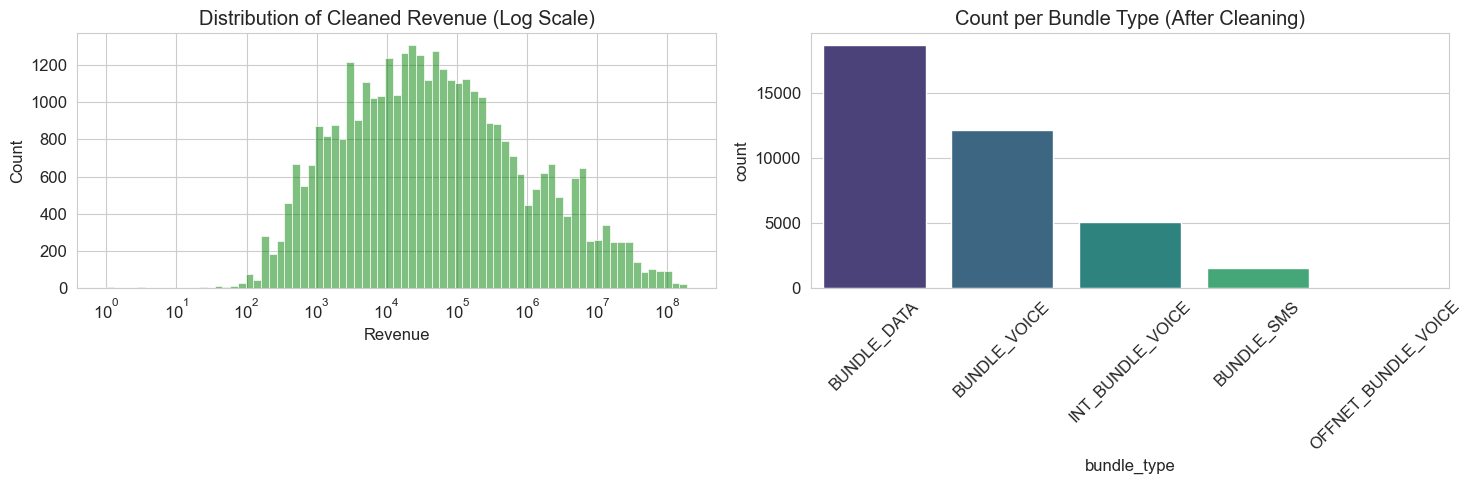


   - Number of records with zero value: 8
   - Final dataset size: 37475 rows


In [13]:

print(" --- Checking Revenue Processing Results --- ")


negative_count = (df['total_rev'] < 0).sum()
print(f"Found {negative_count} records with negative revenue. Dropping them...")


desc_before = df['total_rev'].describe()


df = df[df['total_rev'] >= 0].copy()


df['total_rev_clean'] = df['total_rev']


print("\nStatistical Comparison (Before and After Dropping):")
comparison = pd.DataFrame({
    'Original (With Negatives)': desc_before,
    'Cleaned (Dropped Negatives)': df['total_rev_clean'].describe()
})
display(comparison)


plt.figure(figsize=(15, 5))


plt.subplot(1, 2, 1)
sns.histplot(df['total_rev_clean'], kde=True, color='green', log_scale=True)
plt.title('Distribution of Cleaned Revenue (Log Scale)')
plt.xlabel('Revenue')


plt.subplot(1, 2, 2)
sns.countplot(data=df, x='bundle_type', palette='viridis', order=df['bundle_type'].value_counts().index)
plt.title('Count per Bundle Type (After Cleaning)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


zeros_count = (df['total_rev_clean'] == 0).sum()
print(f"\n   - Number of records with zero value: {zeros_count}")
print(f"   - Final dataset size: {df.shape[0]} rows")

##### 9.4. Zero-Revenue Audit

Before removal, records with `total_rev_clean == 0` are inspected. This helps distinguish between:

* **Promotional Bundles**: Items that might have a price but yielded no revenue during the period.

* **Data Anomalies**: Potential logging errors where usage occurred without a recorded financial impact.

In [14]:
zeros_df = df[df['total_rev_clean'] == 0]
print("Records with Zero Revenue:")
display(zeros_df[['bundle_name', 'bundle_type', 'price_clean', 'total_rev_clean']])


df = df[df['total_rev_clean'] > 0].copy()

print(f"\n Zeros have been removed. Final data size: {df.shape[0]} rows.")

Records with Zero Revenue:


,bundle_name,bundle_type,price_clean,total_rev_clean
4150,Forfait Mifi 7 jours 13GB@5500F,BUNDLE_DATA,5500.00,0.00
5358,NDAKO BOX 150GB@35000F,BUNDLE_DATA,35000.00,0.00
7579,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,50050.00,0.00
10895,MTNBIZ+ 150GB@35000F,BUNDLE_DATA,35000.00,0.00
18139,FORFAIT Mifi 37538 MB 7 Jours@10000F,BUNDLE_DATA,10000.00,0.00
20720,FORFAIT Mifi 37538 MB 7 Jours@10000F,BUNDLE_DATA,10000.00,0.00
21471,FORFAIT Mifi 37538 MB 7 Jours@10000F,BUNDLE_DATA,10000.00,0.00
34501,Voice Bundle 31 Days @5742F 224min,BUNDLE_VOICE,5742.00,0.00



 Zeros have been removed. Final data size: 37467 rows.


In [15]:
df['total_rev_clean_log'] = np.log1p(df['total_rev_clean'])
display(df[['total_rev_clean', 'total_rev_clean_log']].head(10))

,total_rev_clean,total_rev_clean_log
0,36000.00,10.49
1,3450.00,8.15
2,400.00,5.99
3,124060.00,11.73
4,200200.00,12.21
5,37500.00,10.53
6,56640.00,10.94
7,17161358.36,16.66
8,10018029.99,16.12
9,10850.00,9.29


### 10. Intelligent Service Class Classification

This section addresses missing values in the `service_class_category` by implementing a rule-based classification engine. It uses keywords within the bundle names to categorize subscribers into distinct service tiers.

##### 10.1. Classification Logic

The `fill_service_class` function applies a hierarchical approach to determine the correct category:

* **Preservation**: If a category already exists, it is standardized to uppercase and retained.

* **Keyword Inference**: For missing values, the function scans the `bundle_name` for specific identifiers:
   
   * ***POSTPAID***: Triggered by corporate or fixed-line keywords (e.g., corpo, business, ebu, post, fixe).

   * ***HYBRID***: Triggered by terms indicating mixed billing (e.g., hybrid, mixte).

   * ***PREPAID (Default)***: Assigned to all remaining records, as it represents the standard consumer baseline.

##### 10.2. Data Standardization

* **Consistency**: Ensures all entries are uniform in casing and spacing, which is vital for categorical encoding and grouping operations.

* **Frequency Audit**: The final `value_counts()` output provides a snapshot of the subscriber base distribution, allowing for a quick sanity check of the rule-based assignments.



In [16]:
def fill_service_class(row):
    
    if pd.notna(row['service_class_category']):
        return str(row['service_class_category']).upper().strip()
    
    name = str(row['bundle_name']).lower()
    
    
    if any(word in name for word in ['corpo', 'business', 'ebu', 'post', 'fixe']):
        return 'POSTPAID'
    
    if any(word in name for word in ['hybrid', 'mixte']):
        return 'HYBRID'
    
    
    return 'PREPAID'


df['service_class_category'] = df.apply(fill_service_class, axis=1)


print(df['service_class_category'].value_counts())


service_class_category
PREPAID     27919
HYBRID       9483
POSTPAID       65
Name: count, dtype: int64


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37467 entries, 0 to 37610
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   week_number             37467 non-null  int64  
 1   year_number             37467 non-null  int64  
 2   bundle_id               37467 non-null  object 
 3   bundle_name             37467 non-null  object 
 4   bundle_type             37467 non-null  object 
 5   validity                37467 non-null  object 
 6   price                   37467 non-null  object 
 7   configured_volume       36543 non-null  object 
 8   service_class_category  37467 non-null  object 
 9   total_rev               37467 non-null  float64
 10  total_subscriptions     37467 non-null  int64  
 11  total_sessions          37467 non-null  int64  
 12  unique_users            37467 non-null  int64  
 13  validity_hours_clean    37467 non-null  float64
 14  validity_hours_log      37467 non-null  flo

In [ ]:
df.to_csv('clean_dataset.csv', index=False)

In [18]:
columns_for_training = [
    'bundle_type', 
    'service_class_category', 
    'is_unlimited_volume',
    'volume_MB_log',
    'volume_min_log',
    'volume_SMS_log',
    'validity_hours_log',
    'price_clean_log'
]
df_train = df[columns_for_training]
df_train.to_csv('training_dataset.csv', index=False)
df_train = df[columns_for_training].copy()

In [19]:
df_train['is_unlimited_volume'] = df_train['is_unlimited_volume'].astype(bool)


assert df_train.isna().sum().sum() == 0, "Warning: There are still missing values in the training data!"


print("Training data shape:", df_train.shape)
display(df_train.head(5))

Training data shape: (37467, 8)


,bundle_type,service_class_category,is_unlimited_volume,volume_MB_log,volume_min_log,volume_SMS_log,validity_hours_log,price_clean_log
0,BUNDLE_DATA,PREPAID,False,7.41,0.00,0.00,6.58,8.29
1,INT_BUNDLE_VOICE,PREPAID,False,0.00,1.10,0.00,6.58,6.54
2,INT_BUNDLE_VOICE,PREPAID,False,0.00,1.10,0.00,6.58,5.30
3,BUNDLE_DATA,PREPAID,False,5.14,0.00,0.00,3.22,5.38
4,BUNDLE_DATA,PREPAID,True,11.94,0.00,0.00,6.58,10.82


### 11. Metadata Detection and Schema Definition

In preparation for synthetic data generation and advanced modeling, this step utilizes the Synthetic Data Vault (SDV) library to automatically map the dataset's schema.

##### 11.1. Schema Automated Mapping

The `SingleTableMetadata` object is initialized to analyze the `df_train` DataFrame. This process serves several critical functions:

*  **Data Type Identification**: Automatically distinguishes between numerical, categorical, and datetime columns.

* **Primary Key Detection**: Identifies unique identifiers (if present) to maintain relational integrity.

* **Statistical Profiling**: Captures the range, distribution, and constraints of each feature, which is essential for the ***TVAE (Tabular Variational Autoencoder)*** to generate realistic data later.

##### 11.2. Metadata Verification

By printing the `metadata.to_dict()`, we can audit how the model perceives our features. This ensures that:

* Standardized volumes (`volume_MB`, `volume_min`) are recognized as ***numerical***.

* Classifications (`service_class_category`, `bundle_type`) are correctly flagged as ***categorical***.

* Any sensitive information is properly identified for potential anonymization.



In [ ]:

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_train)


print("Detected Metadata:")
print(metadata.to_dict())

Detected Metadata:
{'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1', 'columns': {'bundle_type': {'sdtype': 'categorical'}, 'service_class_category': {'sdtype': 'categorical'}, 'is_unlimited_volume': {'sdtype': 'categorical'}, 'volume_MB_log': {'sdtype': 'numerical'}, 'volume_min_log': {'sdtype': 'numerical'}, 'volume_SMS_log': {'sdtype': 'numerical'}, 'validity_hours_log': {'sdtype': 'numerical'}, 'price_clean_log': {'sdtype': 'numerical'}}}


In [ ]:

import time

print("="*50)
print(" Initializing TVAE Synthesizer...")
print("="*50)

start_time = time.time()

synthesizer = TVAESynthesizer(
    metadata,
    epochs=400,
    batch_size=100,
    cuda=True,
    verbose=True  
)

print("\n Training started...")
print(f"Dataset shape: {df_train.shape}")
print(f"Epochs: 300 | Batch size: 500 | GPU: Enabled\n")


synthesizer.fit(df_train)

end_time = time.time()

print("\n" + "="*50)
print(" Training completed!")
print("="*50)

print(f" Total training time: {(end_time - start_time):.2f} seconds")


model_path = 'tvae_bundle_model.pkl'
synthesizer.save(model_path)

print(f" Model saved at: {model_path}")

 Initializing TVAE Synthesizer...

 Training started...
Dataset shape: (37467, 8)
Epochs: 300 | Batch size: 500 | GPU: Enabled



Loss: -29.97: 100%|██████████| 400/400 [21:25<00:00,  3.21s/it]


 Training completed!
 Total training time: 1326.96 seconds
 Model saved at: tvae_bundle_model.pkl


In [ ]:

num_new_bundles = 5000
print(f"Generating {num_new_bundles} new synthetic bundles...")


synthetic_raw = synthesizer.sample(num_rows=num_new_bundles)

print("Raw Generation Complete. Sample:")
display(synthetic_raw.head(10))

Generating 5000 new synthetic bundles...
Raw Generation Complete. Sample:


,bundle_type,service_class_category,is_unlimited_volume,volume_MB_log,volume_min_log,volume_SMS_log,validity_hours_log,price_clean_log
0,BUNDLE_VOICE,PREPAID,False,0.000000,6.374877,0.000000,6.580273,7.187853
1,INT_BUNDLE_VOICE,PREPAID,False,0.000992,2.755569,0.000174,6.580243,7.976242
2,BUNDLE_DATA,PREPAID,False,5.933531,0.000000,0.000000,5.128861,6.780451
3,BUNDLE_VOICE,PREPAID,False,0.000428,2.682868,0.000000,3.893248,5.065348
4,BUNDLE_VOICE,PREPAID,False,0.000000,1.792828,0.000000,3.217951,5.496705
5,INT_BUNDLE_VOICE,PREPAID,False,0.000736,1.795302,0.000158,6.579782,7.585395
6,BUNDLE_DATA,PREPAID,False,8.008481,0.000000,0.000000,3.219366,5.398081
7,BUNDLE_VOICE,HYBRID,False,0.000830,0.000044,5.865388,5.131047,7.607755
8,BUNDLE_DATA,PREPAID,False,8.238230,0.000149,0.000182,5.130291,7.835251
9,BUNDLE_DATA,PREPAID,False,5.003411,0.000000,0.000167,3.218448,4.931712


In [ ]:


synthetic_final = synthetic_raw.copy()


synthetic_final['volume_MB'] = np.expm1(synthetic_final['volume_MB_log'])
synthetic_final['volume_min'] = np.expm1(synthetic_final['volume_min_log'])
synthetic_final['volume_SMS'] = np.expm1(synthetic_final['volume_SMS_log'])
synthetic_final['validity_hours'] = np.expm1(synthetic_final['validity_hours_log'])
synthetic_final['price_clean'] = np.expm1(synthetic_final['price_clean_log'])



if 'is_unlimited_volume' in synthetic_final.columns:
    synthetic_final.loc[synthetic_final['is_unlimited_volume'] == True, 'volume_MB'] = -1


synthetic_final['volume_MB'] = synthetic_final['volume_MB'].round(0).astype(int)
synthetic_final['volume_min'] = synthetic_final['volume_min'].round(0).astype(int)
synthetic_final['volume_SMS'] = synthetic_final['volume_SMS'].round(0).astype(int)
synthetic_final['validity_hours'] = synthetic_final['validity_hours'].round(0).astype(int)


synthetic_final['price_clean'] = synthetic_final['price_clean'].round(2)


synthetic_final.rename(columns={'price_clean': 'baseline_price'}, inplace=True)


cols_to_drop = [col for col in synthetic_final.columns if col.endswith('_log')]
synthetic_final.drop(columns=cols_to_drop, inplace=True)

print("Post-processing complete!")

Post-processing complete!


In [ ]:

final_columns_order = [
    'bundle_type',
    'service_class_category',
    'is_unlimited_volume',
    'volume_MB',
    'volume_min',
    'volume_SMS',
    'validity_hours',
    'baseline_price'
]

synthetic_bundles_ready = synthetic_final[final_columns_order]

print("=== FINAL SYNTHETIC BUNDLES (READY FOR PRICING & POPULARITY MODELS) ===")
display(synthetic_bundles_ready.head(10))


synthetic_bundles_ready.to_csv('synthetic_telecom_bundles.csv', index=False)

=== FINAL SYNTHETIC BUNDLES (READY FOR PRICING & POPULARITY MODELS) ===


,bundle_type,service_class_category,is_unlimited_volume,volume_MB,volume_min,volume_SMS,validity_hours,baseline_price
0,BUNDLE_VOICE,PREPAID,False,0,586,0,720,1322.26
1,INT_BUNDLE_VOICE,PREPAID,False,0,15,0,720,2909.97
2,BUNDLE_DATA,PREPAID,False,376,0,0,168,879.47
3,BUNDLE_VOICE,PREPAID,False,0,14,0,48,157.44
4,BUNDLE_VOICE,PREPAID,False,0,5,0,24,242.89
5,INT_BUNDLE_VOICE,PREPAID,False,0,5,0,719,1968.23
6,BUNDLE_DATA,PREPAID,False,3005,0,0,24,219.98
7,BUNDLE_VOICE,HYBRID,False,0,0,352,168,2012.75
8,BUNDLE_DATA,PREPAID,False,3782,0,0,168,2527.17
9,BUNDLE_DATA,PREPAID,False,148,0,0,24,137.62


In [ ]:
import pandas as pd
import numpy as np
from sdv.evaluation.single_table import evaluate_quality
from sdmetrics.single_table import NewRowSynthesis
from sklearn.neighbors import NearestNeighbors

def evaluate_synthetic_data_pro(real_data, synthetic_data, metadata_dict):
    print("="*60)
    print(" INITIATING PROFESSIONAL EVALUATION SUITE")
    print("="*60)

   
    print("\n[1] Calculating Core Quality Metrics (SDV)...")
    quality_report = evaluate_quality(
    real_data=df_train,
    synthetic_data=synthetic_raw,
    metadata=metadata
)


    
    properties = quality_report.get_properties()
    print("\n--- Summary Properties ---")
    display(properties)


    print("\n[2] Detailed Statistical Tests (KS-Test for Num, TV-Test for Cat)...")
   
    column_details = quality_report.get_details(property_name='Column Shapes')
    
    column_details = column_details[['Column', 'Metric', 'Score']].sort_values(by='Score', ascending=False)
    display(column_details)


    print("\n[3] Calculating Duplicate Ratios...")

    
    internal_dupes = synthetic_raw.duplicated().mean()


    novelty_score = NewRowSynthesis.compute(df_train, synthetic_raw, metadata_dict)
    exact_copy_ratio = 1.0 - novelty_score

    print(f" * Internal Duplication Ratio (Mode collapse check): {internal_dupes:.2%}")
    print(f" * Exact Copy Ratio (Overfitting to Real data): {exact_copy_ratio:.2%}")


    print("\n[4] Calculating Duplicate Approximation (Distance to Closest Real Record)...")
    
    real_numeric = pd.get_dummies(df_train).astype(float)
    synth_numeric = pd.get_dummies(synthetic_raw).astype(float)

    
    synth_numeric = synth_numeric.reindex(columns=real_numeric.columns, fill_value=0)

    
    knn = NearestNeighbors(n_neighbors=1)
    knn.fit(real_numeric)
    distances, _ = knn.kneighbors(synth_numeric)

    
    avg_distance = np.mean(distances)
    threshold_distance = 0.5 # حد تقريبي
    very_close_ratio = (distances < threshold_distance).mean()

    print(f" * Average Distance to nearest real record: {avg_distance:.4f}")
    print(f" * Ratio of synthetics 'very close' (< {threshold_distance}) to real: {very_close_ratio:.2%}")

    print("\n" + "="*60)
    print(" EVALUATION COMPLETE")
    print("="*60)

    return quality_report 


final_report = evaluate_synthetic_data_pro(df_train, synthetic_bundles_ready, metadata.to_dict())

 INITIATING PROFESSIONAL EVALUATION SUITE

[1] Calculating Core Quality Metrics (SDV)...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 8/8 [00:00<00:00, 140.67it/s]|
Column Shapes Score: 80.78%

(2/2) Evaluating Column Pair Trends: |██████████| 28/28 [00:00<00:00, 106.76it/s]|
Column Pair Trends Score: 85.18%

Overall Score (Average): 82.98%


--- Summary Properties ---


,Property,Score
0,Column Shapes,0.807777
1,Column Pair Trends,0.851848



[2] Detailed Statistical Tests (KS-Test for Num, TV-Test for Cat)...


,Column,Metric,Score
2,is_unlimited_volume,TVComplement,0.990949
0,bundle_type,TVComplement,0.962978
7,price_clean_log,KSComplement,0.949116
6,validity_hours_log,KSComplement,0.809679
1,service_class_category,TVComplement,0.779162
3,volume_MB_log,KSComplement,0.756702
4,volume_min_log,KSComplement,0.715286
5,volume_SMS_log,KSComplement,0.498344



[3] Calculating Duplicate Ratios...
 * Internal Duplication Ratio (Mode collapse check): 0.00%
 * Exact Copy Ratio (Overfitting to Real data): 4.58%

[4] Calculating Duplicate Approximation (Distance to Closest Real Record)...
 * Average Distance to nearest real record: 0.3307
 * Ratio of synthetics 'very close' (< 0.5) to real: 84.26%

 EVALUATION COMPLETE


Generating Plot 1: Histogram Overlay (Volume & Minutes)...


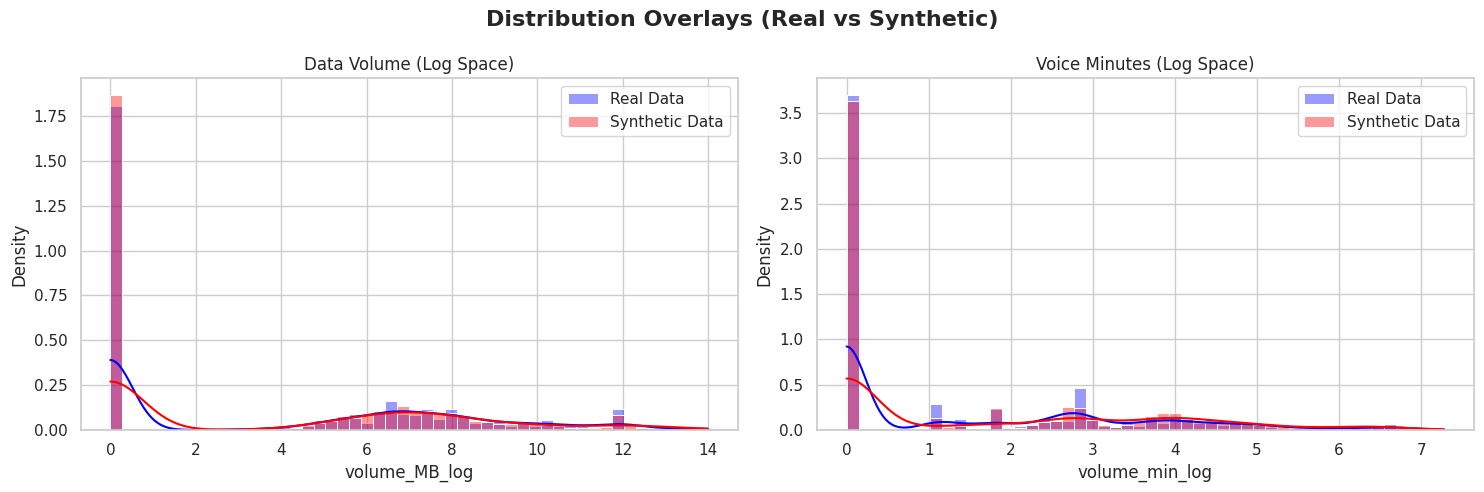

Generating Plot 2: PCA 2D Projection...


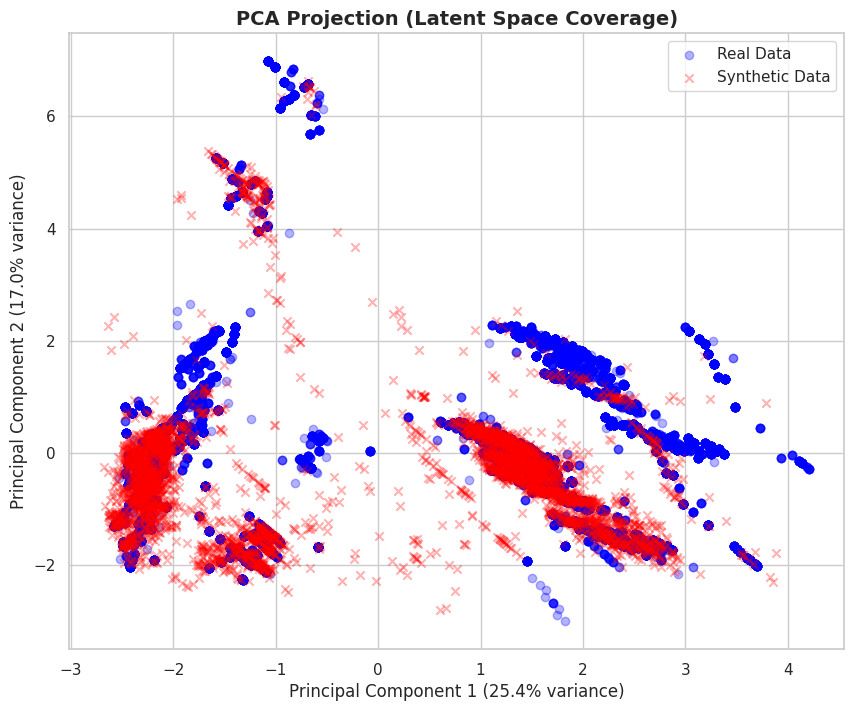

Generating Plot 3: Quality Scores per Column...


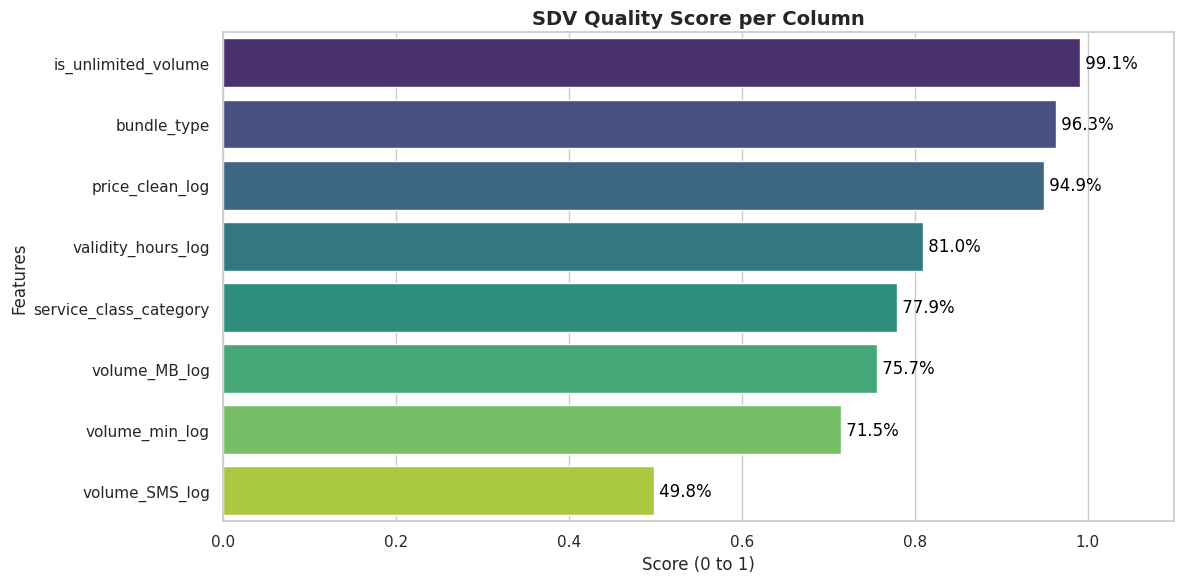

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def generate_thesis_visualizations(real_raw, synth_raw, synthesizer, report):

    sns.set_theme(style="whitegrid")



    print("Generating Plot 1: Histogram Overlay (Volume & Minutes)...")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('Distribution Overlays (Real vs Synthetic)', fontsize=16, fontweight='bold')

    columns_to_plot = ['volume_MB_log', 'volume_min_log']
    titles = ['Data Volume (Log Space)', 'Voice Minutes (Log Space)']

    for i, col in enumerate(columns_to_plot):
        sns.histplot(real_raw[col], color='blue', label='Real Data', kde=True, stat="density", bins=50, alpha=0.4, ax=axes[i])
        sns.histplot(synth_raw[col], color='red', label='Synthetic Data', kde=True, stat="density", bins=50, alpha=0.4, ax=axes[i])
        axes[i].set_title(titles[i])
        axes[i].legend()

    plt.tight_layout()
    plt.show()



    print("Generating Plot 2: PCA 2D Projection...")
    
    real_encoded = pd.get_dummies(real_raw).astype(float)
    synth_encoded = pd.get_dummies(synth_raw).astype(float)

    
    synth_encoded = synth_encoded.reindex(columns=real_encoded.columns, fill_value=0)

    
    combined_data = pd.concat([real_encoded, synth_encoded], axis=0)
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(combined_data)

    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(scaled_data)

    
    n_real = len(real_encoded)
    pca_real = pca_result[:n_real]
    pca_synth = pca_result[n_real:]

    plt.figure(figsize=(10, 8))
    plt.scatter(pca_real[:, 0], pca_real[:, 1], c='blue', alpha=0.3, label='Real Data', marker='o')
    plt.scatter(pca_synth[:, 0], pca_synth[:, 1], c='red', alpha=0.3, label='Synthetic Data', marker='x')
    plt.title('PCA Projection (Latent Space Coverage)', fontsize=14, fontweight='bold')
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.legend()
    plt.show()


    print("Generating Plot 3: Quality Scores per Column...")
    column_details = report.get_details(property_name='Column Shapes')
    column_details = column_details.sort_values(by='Score', ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=column_details, x='Score', y='Column', palette='viridis')

    
    for index, value in enumerate(column_details['Score']):
        plt.text(value, index, f' {value:.1%}', color='black', va="center")

    plt.title('SDV Quality Score per Column', fontsize=14, fontweight='bold')
    plt.xlabel('Score (0 to 1)')
    plt.ylabel('Features')
    plt.xlim(0, 1.1)
    plt.tight_layout()
    plt.show()



generate_thesis_visualizations(df_train, synthetic_raw, synthesizer, final_report)

In [19]:
display(df_train.describe())
display(synthetic_raw.describe())

,volume_MB_log,volume_min_log,volume_SMS_log,validity_hours_log,price_clean_log
count,37467.000000,37467.000000,37467.000000,37467.000000,37467.000000
mean,3.900200,1.519575,0.201205,4.792671,6.910284
std,4.245164,1.914017,0.979934,1.354721,1.586201
min,0.000000,0.000000,0.000000,1.098612,2.397895
25%,0.000000,0.000000,0.000000,3.218876,5.860786
50%,0.000000,0.000000,0.000000,4.795791,6.552508
75%,7.337588,2.772589,0.000000,6.580639,7.832411
max,13.996232,7.280008,6.957497,9.064274,14.246644


,volume_MB_log,volume_min_log,volume_SMS_log,validity_hours_log,price_clean_log
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,3.778747,1.699021,0.193672,4.854771,6.955793
std,4.245074,2.043197,0.991788,1.263019,1.467071
min,0.000000,0.000000,0.000000,3.216747,2.397895
25%,0.000000,0.000000,0.000000,3.220128,5.994244
50%,0.003435,0.001424,0.000026,5.129248,6.653504
75%,7.319792,3.542423,0.000186,6.579256,7.881993
max,13.996232,7.280008,6.818825,6.593830,13.256378


In [ ]:

duplicates = pd.merge(df_train, synthetic_raw, how='inner')
exact_match_ratio = (len(duplicates) / len(synthetic_raw)) * 100

print(f"Exact Matches: {exact_match_ratio:.2f}%")

Exact Matches: 0.00%


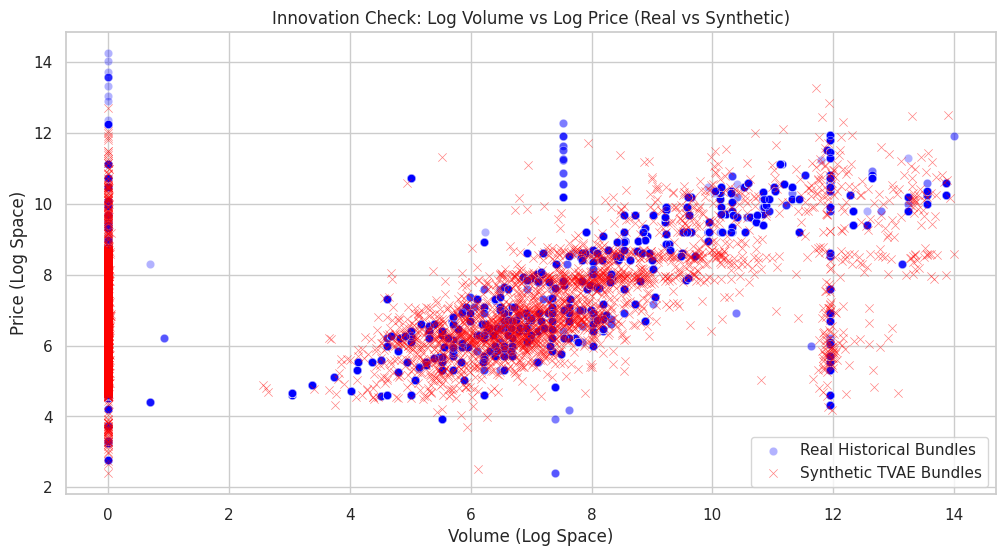

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))


sns.scatterplot(
    data=df_train,
    x='volume_MB_log', y='price_clean_log',
    color='blue', alpha=0.3, label='Real Historical Bundles'
)


sns.scatterplot(
    data=synthetic_raw,
    x='volume_MB_log', y='price_clean_log',
    color='red', alpha=0.5, marker='x', label='Synthetic TVAE Bundles'
)


plt.title('Innovation Check: Log Volume vs Log Price (Real vs Synthetic)')
plt.xlabel('Volume (Log Space)')
plt.ylabel('Price (Log Space)')
plt.legend()
plt.show()



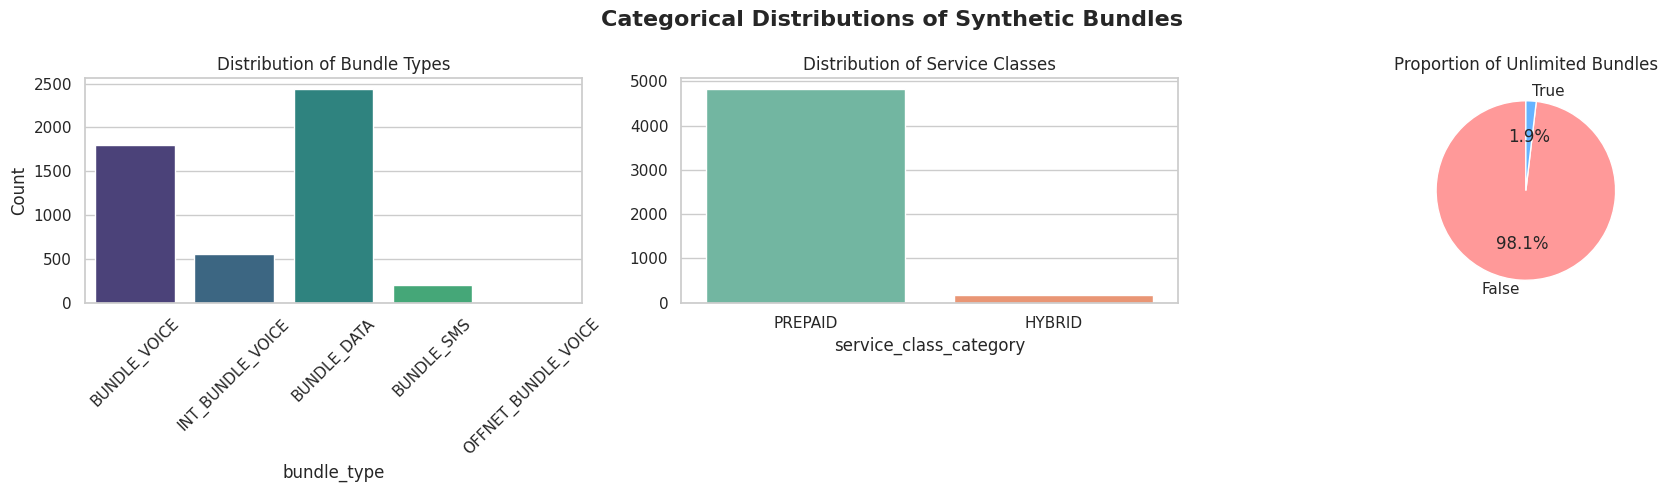

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Categorical Distributions of Synthetic Bundles', fontsize=16, fontweight='bold')


sns.countplot(data=synthetic_bundles_ready, x='bundle_type', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Bundle Types')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Count')


sns.countplot(data=synthetic_bundles_ready, x='service_class_category', ax=axes[1], palette='Set2')
axes[1].set_title('Distribution of Service Classes')
axes[1].set_ylabel('')


synthetic_bundles_ready['is_unlimited_volume'].value_counts().plot.pie(
    ax=axes[2], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff']
)
axes[2].set_title('Proportion of Unlimited Bundles')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

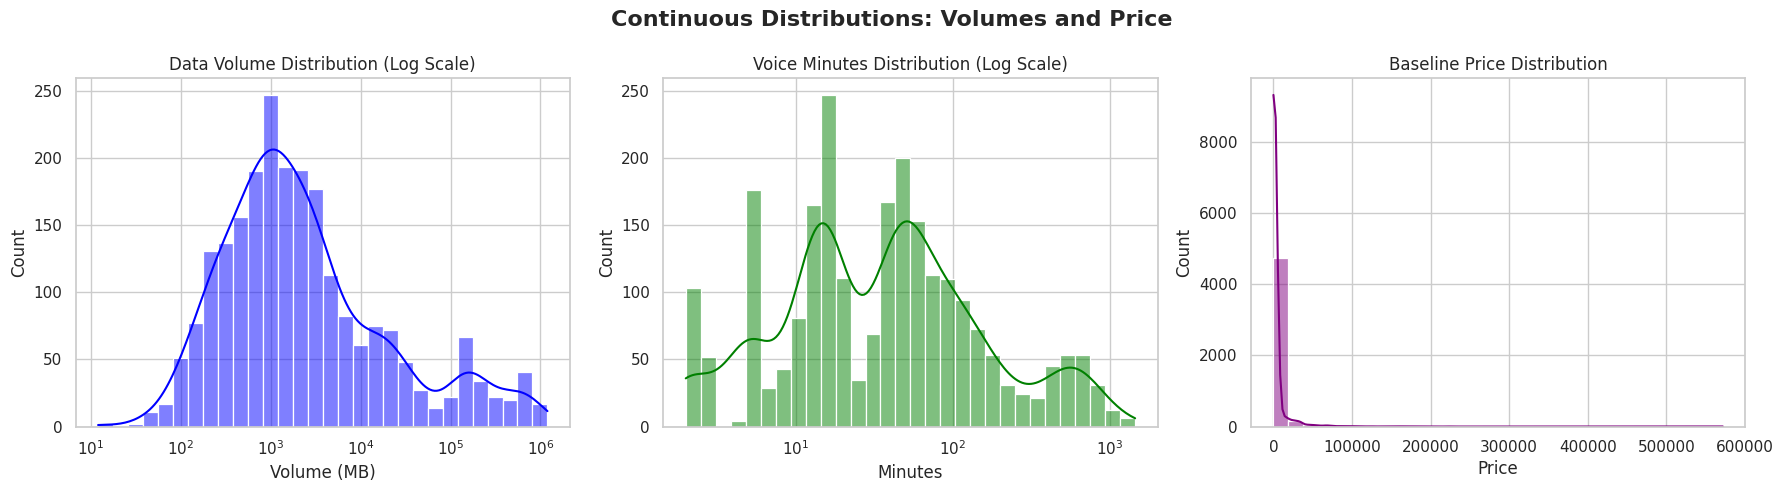

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Continuous Distributions: Volumes and Price', fontsize=16, fontweight='bold')


sns.histplot(data=synthetic_bundles_ready[synthetic_bundles_ready['volume_MB'] > 0],
             x='volume_MB', bins=30, kde=True, ax=axes[0], color='blue', log_scale=True)
axes[0].set_title('Data Volume Distribution (Log Scale)')
axes[0].set_xlabel('Volume (MB)')


sns.histplot(data=synthetic_bundles_ready[synthetic_bundles_ready['volume_min'] > 0],
             x='volume_min', bins=30, kde=True, ax=axes[1], color='green', log_scale=True)
axes[1].set_title('Voice Minutes Distribution (Log Scale)')
axes[1].set_xlabel('Minutes')


sns.histplot(data=synthetic_bundles_ready,
             x='baseline_price', bins=30, kde=True, ax=axes[2], color='purple')
axes[2].set_title('Baseline Price Distribution')
axes[2].set_xlabel('Price')

plt.tight_layout()
plt.show()

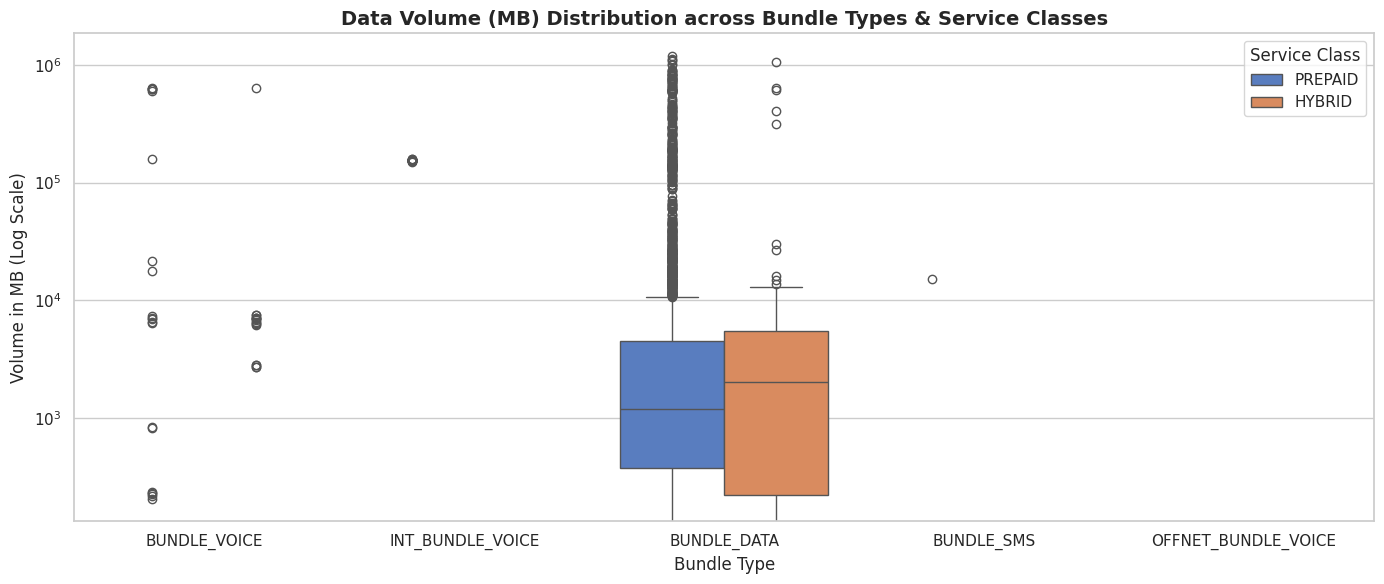

--- Summary Statistics for Synthetic Volumes (MB) by Bundle Type ---


,count,mean,std,min,25%,50%,75%,max
bundle_type,,,,,,,,
BUNDLE_DATA,2439.0,33203.76,124408.03,-1.0,370.5,1219.0,4667.5,1198080.0
BUNDLE_SMS,197.0,76.89,1079.25,-1.0,0.0,0.0,0.0,15148.0
BUNDLE_VOICE,1804.0,2246.33,36025.74,-1.0,0.0,0.0,0.0,635354.0
INT_BUNDLE_VOICE,559.0,5252.09,28027.98,0.0,0.0,0.0,0.0,158407.0
OFFNET_BUNDLE_VOICE,1.0,0.00,NaN,0.0,0.0,0.0,0.0,0.0


In [ ]:
plt.figure(figsize=(14, 6))


sns.boxplot(data=synthetic_bundles_ready,
            x='bundle_type',
            y='volume_MB',
            hue='service_class_category',
            palette='muted')


plt.yscale('log')
plt.title('Data Volume (MB) Distribution across Bundle Types & Service Classes', fontsize=14, fontweight='bold')
plt.ylabel('Volume in MB (Log Scale)')
plt.xlabel('Bundle Type')
plt.legend(title='Service Class')

plt.tight_layout()
plt.show()


print("--- Summary Statistics for Synthetic Volumes (MB) by Bundle Type ---")
display(synthetic_bundles_ready.groupby('bundle_type')['volume_MB'].describe().round(2))

In [ ]:
# train 2

### 12. Model Training and Synthetic Data Evaluation

This final stage involves splitting the dataset, training the generative model, and rigorously evaluating the quality of the produced synthetic data. The objective is to ensure the ***TVAE*** model captures the underlying distribution of the real data without overfitting.

##### 12.1. Stratified Data Splitting

To ensure the model learns from a representative sample of all product offerings, the data is split using ***Stratification***:

* **Mechanism**: `train_test_split` is applied with the `stratify` parameter targeting `bundle_type`.

* **Purpose**: This maintains the same percentage of Voice, Data, and SMS bundles in both the training and testing sets, preventing the model from being biased toward the majority class.

##### 12.2. TVAE Model Initialization & Training

The ***Tabular Variational Autoencoder (TVAE)*** is configured for high-fidelity data generation:

* **Parameters**: Trained for ***500 epochs*** with a*** batch size of 200***.

* **Hardware Acceleration**: `cuda=True` is enabled to utilize GPU processing, significantly reducing training time for the neural network layers..

* **Fitting**: The synthesizer learns the multidimensional correlations and statistical constraints defined in the previously detected metadata.

##### 12.3. Synthetic Sampling and Quality Benchmarking

After training, the model generates a `synthetic_sample` equal in size to the test set for a direct "apples-to-apples" comparison.

* **Quality Evaluation**: Using `evaluate_quality`, the synthetic data is compared against both the training and testing sets.

* **Metric Scoring**: The resulting scores represent how well the synthetic data mimics:

   * ***Column Shapes***: Individual feature distributions.

   * ***Column Pair Trends***: Correlations between different features (e.g., the relationship between Price and Volume).


##### 12.4. Performance Audit

The final output provides two percentage-based scores. A high, balanced score across both ***Training*** and ***Testing*** indicates that the model has generalized well and is capable of producing realistic, privacy-preserving synthetic records.



In [ ]:
from sklearn.model_selection import train_test_split
from sdv.evaluation.single_table import evaluate_quality


train_data, test_data = train_test_split(
    df_train,
    test_size=0.2,
    random_state=42,
    stratify=df_train['bundle_type'] 
)


print("=== Percentage of categories in total data ===")
print((df_train['bundle_type'].value_counts(normalize=True) * 100).round(2))

print("\n=== Percentage of categories in training data ===")
print((train_data['bundle_type'].value_counts(normalize=True) * 100).round(2))

synthesizer = TVAESynthesizer(
    metadata,
    epochs=500,
    batch_size=200,
    cuda=True,
    verbose=True   
)


synthesizer.fit(train_data)


synthetic_sample = synthesizer.sample(num_rows=len(test_data))


print("--- Evaluating the quality of data on the training set (Train) ---")
train_report = evaluate_quality(train_data, synthetic_sample, metadata)
score_train = train_report.get_score()

print("\n--- Evaluating the quality of data on the test set ---")
test_report = evaluate_quality(test_data, synthetic_sample, metadata)
score_test = test_report.get_score()

print(f"\nTraining Score: {score_train:.2%}")
print(f"Testing Score:  {score_test:.2%}")

=== Percentage of categories in total data ===
bundle_type
BUNDLE_DATA            49.77
BUNDLE_VOICE           32.38
INT_BUNDLE_VOICE       13.52
BUNDLE_SMS              4.21
OFFNET_BUNDLE_VOICE     0.12
Name: proportion, dtype: float64

=== Percentage of categories in training data ===
bundle_type
BUNDLE_DATA            49.76
BUNDLE_VOICE           32.38
INT_BUNDLE_VOICE       13.52
BUNDLE_SMS              4.21
OFFNET_BUNDLE_VOICE     0.12
Name: proportion, dtype: float64


Loss: -30.21: 100%|██████████| 500/500 [10:53<00:00,  1.31s/it]


--- Evaluating the quality of data on the training set (Train) ---
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 8/8 [00:00<00:00, 165.52it/s]|
Column Shapes Score: 81.06%

(2/2) Evaluating Column Pair Trends: |██████████| 28/28 [00:00<00:00, 109.83it/s]|
Column Pair Trends Score: 85.26%

Overall Score (Average): 83.16%


--- Evaluating the quality of data on the test set ---
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 8/8 [00:00<00:00, 159.79it/s]|
Column Shapes Score: 80.88%

(2/2) Evaluating Column Pair Trends: |██████████| 28/28 [00:00<00:00, 159.76it/s]|
Column Pair Trends Score: 87.14%

Overall Score (Average): 84.01%


Training Score: 83.16%
Testing Score:  84.01%


In [ ]:

model_path = 'tvae_bundle_model_improved.pkl'
synthesizer.save(model_path)

### 13. Production-Scale Synthetic Data Generation


This stage focuses on generating a large-scale batch of new and synthetic packet records, for use in subsequent stages.

In [ ]:

num_new_bundles = 5000
print(f"Generating {num_new_bundles} new synthetic bundles...")


synthetic_raw = synthesizer.sample(num_rows=num_new_bundles)

print("Raw Generation Complete. Sample:")
display(synthetic_raw.head(10))

Generating 5000 new synthetic bundles...
Raw Generation Complete. Sample:


,bundle_type,service_class_category,is_unlimited_volume,volume_MB_log,volume_min_log,volume_SMS_log,validity_hours_log,price_clean_log
0,INT_BUNDLE_VOICE,PREPAID,False,0.017072,0.000000,0.000000,6.582047,7.093995
1,BUNDLE_VOICE,PREPAID,False,0.000335,5.204989,0.000246,6.582133,7.317184
2,INT_BUNDLE_VOICE,PREPAID,False,0.000000,1.893502,0.000000,6.579459,6.558209
3,INT_BUNDLE_VOICE,PREPAID,False,0.000000,1.100507,0.000603,6.580034,5.939339
4,BUNDLE_VOICE,HYBRID,False,0.002498,4.855942,0.000054,5.129432,7.890433
5,BUNDLE_VOICE,PREPAID,False,0.000000,1.446942,0.000019,6.581107,6.170245
6,BUNDLE_VOICE,PREPAID,False,0.000000,4.191483,0.000449,3.221387,6.298144
7,BUNDLE_DATA,PREPAID,False,5.614983,0.001504,0.000000,3.218565,6.358863
8,BUNDLE_DATA,PREPAID,False,7.298215,0.000454,0.000000,4.291182,6.511620
9,BUNDLE_SMS,PREPAID,False,0.000000,0.000691,0.000160,4.290934,4.709685


### 14. Novelty and Overfitting Validation

This critical validation step assesses whether the TVAE synthesizer is truly creative or merely "memorizing" the training data. High-quality synthetic data must be realistic while remaining distinct from actual user records to ensure privacy and generalization.

##### 14.1. Novelty Scoring

The `NewRowSynthesis` metric measures the "creativity" of the model:

* **Metric**: It calculates the percentage of synthetic rows that represent completely ***new combinations*** of features not found in the original dataset.

* **Goal**: A*** high Novelty Score*** indicates that the model has learned the underlying patterns well enough to generate unique, plausible scenarios rather than just repeating existing ones.


##### 14.2. Overfitting Check (Distance Analysis)

To quantitatively detect potential data leakage or "copy-pasting" from the training set, a ***Nearest Neighbors (KNN)*** approach is used:


* **Pre-processing**: Categorical features are converted via `get_dummies` to transform the data into a high-dimensional numerical space.

* **Distance Calculation**: For every synthetic row, the algorithm finds the Euclidean distance to its closest real-world counterpart.

* **Exact Copy Detection**: Rows with a distance near zero ($< 10^{-5}$) are flagged as exact copies.

##### 14.3. Privacy and Integrity Audit

* Copy Ratio: The `Percentage of Exact Copies` serves as an overfitting KPI. If this ratio is too high, the model poses a privacy risk.

* Distance Distribution: The histogram provides a visual "Safety Buffer" analysis. A healthy model shows most synthetic records at a comfortable distance from the real data, proving it has generalized the distribution rather than memorizing specific points.

In [ ]:
from sdv.evaluation.single_table import get_column_plot
from sdmetrics.single_table import NewRowSynthesis

metadata_dict = metadata.to_dict()

novelty_score = NewRowSynthesis.compute(
    real_data=df_train,
    synthetic_data=synthetic_raw,
    metadata=metadata_dict
)

print(f"Novelty Score (New Combinations): {novelty_score:.2%}")

Novelty Score (New Combinations): 95.90%


Percentage of Exact Copies (Overfit): 0.00%


array([[<Axes: title={'center': 'Distance_to_Closest_Real'}>]],
      dtype=object)

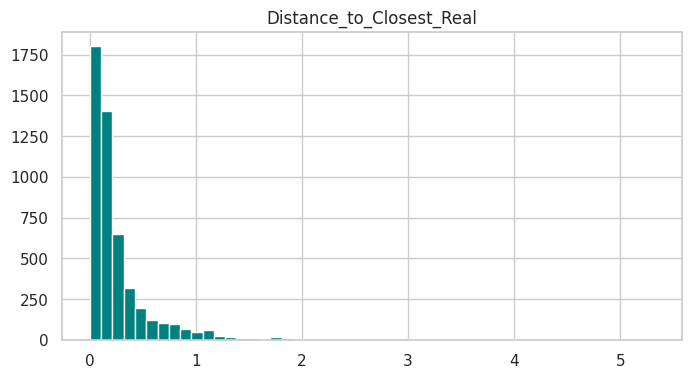

In [ ]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors


def prepare_for_knn(df_in):
    return pd.get_dummies(df_in.drop(columns=['bundle_type', 'service_class_category']), drop_first=True)

real_numeric = prepare_for_knn(df_train)
synth_numeric = prepare_for_knn(synthetic_raw)


knn = NearestNeighbors(n_neighbors=1)
knn.fit(real_numeric)
distances, _ = knn.kneighbors(synth_numeric)


distances_df = pd.DataFrame(distances, columns=['Distance_to_Closest_Real'])


exact_copies = (distances_df['Distance_to_Closest_Real'] < 1e-5).sum()
copy_ratio = exact_copies / len(synth_numeric)

print(f"Percentage of Exact Copies (Overfit): {copy_ratio:.2%}")
distances_df.hist(bins=50, figsize=(8,4), color='teal')

In [ ]:


synthetic_final = synthetic_raw.copy()


synthetic_final['volume_MB'] = np.expm1(synthetic_final['volume_MB_log'])
synthetic_final['volume_min'] = np.expm1(synthetic_final['volume_min_log'])
synthetic_final['volume_SMS'] = np.expm1(synthetic_final['volume_SMS_log'])
synthetic_final['validity_hours'] = np.expm1(synthetic_final['validity_hours_log'])
synthetic_final['price_clean'] = np.expm1(synthetic_final['price_clean_log'])



if 'is_unlimited_volume' in synthetic_final.columns:
    synthetic_final.loc[synthetic_final['is_unlimited_volume'] == True, 'volume_MB'] = -1


synthetic_final['volume_MB'] = synthetic_final['volume_MB'].round(0).astype(int)
synthetic_final['volume_min'] = synthetic_final['volume_min'].round(0).astype(int)
synthetic_final['volume_SMS'] = synthetic_final['volume_SMS'].round(0).astype(int)
synthetic_final['validity_hours'] = synthetic_final['validity_hours'].round(0).astype(int)


synthetic_final['price_clean'] = synthetic_final['price_clean'].round(2)


synthetic_final.rename(columns={'price_clean': 'baseline_price'}, inplace=True)


cols_to_drop = [col for col in synthetic_final.columns if col.endswith('_log')]
synthetic_final.drop(columns=cols_to_drop, inplace=True)

print("Post-processing complete!")

Post-processing complete!


In [ ]:

final_columns_order = [
    'bundle_type',
    'service_class_category',
    'is_unlimited_volume',
    'volume_MB',
    'volume_min',
    'volume_SMS',
    'validity_hours',
    'baseline_price'
]

synthetic_bundles_ready = synthetic_final[final_columns_order]

print("=== FINAL SYNTHETIC BUNDLES (READY FOR PRICING & POPULARITY MODELS) ===")
display(synthetic_bundles_ready.head(10))


synthetic_bundles_ready.to_csv('synthetic_telecom_bundles_improved.csv', index=False)

=== FINAL SYNTHETIC BUNDLES (READY FOR PRICING & POPULARITY MODELS) ===


,bundle_type,service_class_category,is_unlimited_volume,volume_MB,volume_min,volume_SMS,validity_hours,baseline_price
0,INT_BUNDLE_VOICE,PREPAID,False,0,0,0,721,1203.71
1,BUNDLE_VOICE,PREPAID,False,0,181,0,721,1504.96
2,INT_BUNDLE_VOICE,PREPAID,False,0,6,0,719,704.01
3,INT_BUNDLE_VOICE,PREPAID,False,0,2,0,720,378.68
4,BUNDLE_VOICE,HYBRID,False,0,128,0,168,2670.60
5,BUNDLE_VOICE,PREPAID,False,0,3,0,720,477.30
6,BUNDLE_VOICE,PREPAID,False,0,65,0,24,542.56
7,BUNDLE_DATA,PREPAID,False,274,0,0,24,576.59
8,BUNDLE_DATA,PREPAID,False,1477,0,0,72,671.92
9,BUNDLE_SMS,PREPAID,False,0,0,0,72,110.02


In [ ]:
import pandas as pd
import numpy as np
from sdv.evaluation.single_table import evaluate_quality
from sdmetrics.single_table import NewRowSynthesis
from sklearn.neighbors import NearestNeighbors

def evaluate_synthetic_data_pro(real_data, synthetic_data, metadata_dict):
    print("="*60)
    print(" INITIATING PROFESSIONAL EVALUATION SUITE")
    print("="*60)

   
    print("\n[1] Calculating Core Quality Metrics (SDV)...")
    quality_report = evaluate_quality(
    real_data=df_train,
    synthetic_data=synthetic_raw,
    metadata=metadata
)


   
    properties = quality_report.get_properties()
    print("\n--- Summary Properties ---")
    display(properties)


    print("\n[2] Detailed Statistical Tests (KS-Test for Num, TV-Test for Cat)...")
    
    column_details = quality_report.get_details(property_name='Column Shapes')
    
    column_details = column_details[['Column', 'Metric', 'Score']].sort_values(by='Score', ascending=False)
    display(column_details)


    print("\n[3] Calculating Duplicate Ratios...")

   
    internal_dupes = synthetic_raw.duplicated().mean()


    novelty_score = NewRowSynthesis.compute(df_train, synthetic_raw, metadata_dict)
    exact_copy_ratio = 1.0 - novelty_score

    print(f" * Internal Duplication Ratio (Mode collapse check): {internal_dupes:.2%}")
    print(f" * Exact Copy Ratio (Overfitting to Real data): {exact_copy_ratio:.2%}")


    print("\n[4] Calculating Duplicate Approximation (Distance to Closest Real Record)...")
    
    real_numeric = pd.get_dummies(df_train).astype(float)
    synth_numeric = pd.get_dummies(synthetic_raw).astype(float)

    
    synth_numeric = synth_numeric.reindex(columns=real_numeric.columns, fill_value=0)

    
    knn = NearestNeighbors(n_neighbors=1)
    knn.fit(real_numeric)
    distances, _ = knn.kneighbors(synth_numeric)

    
    avg_distance = np.mean(distances)
    threshold_distance = 0.5
    very_close_ratio = (distances < threshold_distance).mean()

    print(f" * Average Distance to nearest real record: {avg_distance:.4f}")
    print(f" * Ratio of synthetics 'very close' (< {threshold_distance}) to real: {very_close_ratio:.2%}")

    print("\n" + "="*60)
    print(" EVALUATION COMPLETE")
    print("="*60)

    return quality_report 


final_report = evaluate_synthetic_data_pro(df_train, synthetic_bundles_ready, metadata.to_dict())

 INITIATING PROFESSIONAL EVALUATION SUITE

[1] Calculating Core Quality Metrics (SDV)...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 8/8 [00:00<00:00, 135.24it/s]|
Column Shapes Score: 81.07%

(2/2) Evaluating Column Pair Trends: |██████████| 28/28 [00:00<00:00, 110.25it/s]|
Column Pair Trends Score: 85.13%

Overall Score (Average): 83.1%


--- Summary Properties ---


,Property,Score
0,Column Shapes,0.810726
1,Column Pair Trends,0.851276



[2] Detailed Statistical Tests (KS-Test for Num, TV-Test for Cat)...


,Column,Metric,Score
2,is_unlimited_volume,TVComplement,0.982749
0,bundle_type,TVComplement,0.966613
7,price_clean_log,KSComplement,0.937674
6,validity_hours_log,KSComplement,0.826680
1,service_class_category,TVComplement,0.795162
3,volume_MB_log,KSComplement,0.736502
4,volume_min_log,KSComplement,0.715486
5,volume_SMS_log,KSComplement,0.524944



[3] Calculating Duplicate Ratios...
 * Internal Duplication Ratio (Mode collapse check): 0.00%
 * Exact Copy Ratio (Overfitting to Real data): 4.10%

[4] Calculating Duplicate Approximation (Distance to Closest Real Record)...
 * Average Distance to nearest real record: 0.3107
 * Ratio of synthetics 'very close' (< 0.5) to real: 83.42%

 EVALUATION COMPLETE


Generating Plot 1: Histogram Overlay (Volume & Minutes)...


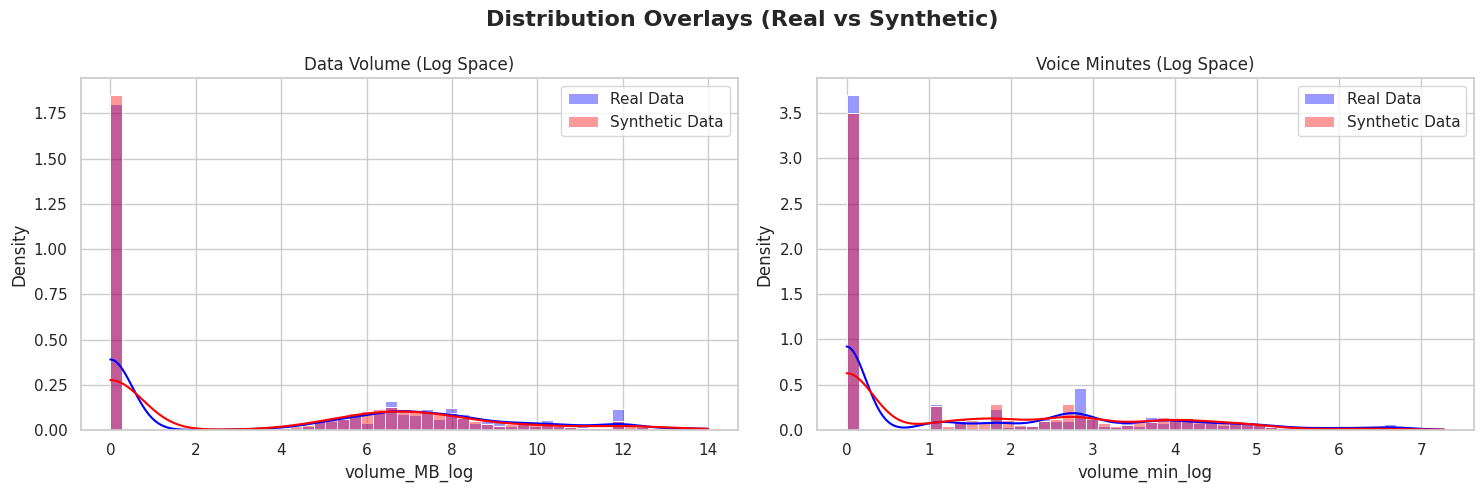

Generating Plot 2: Correlation Heatmaps...


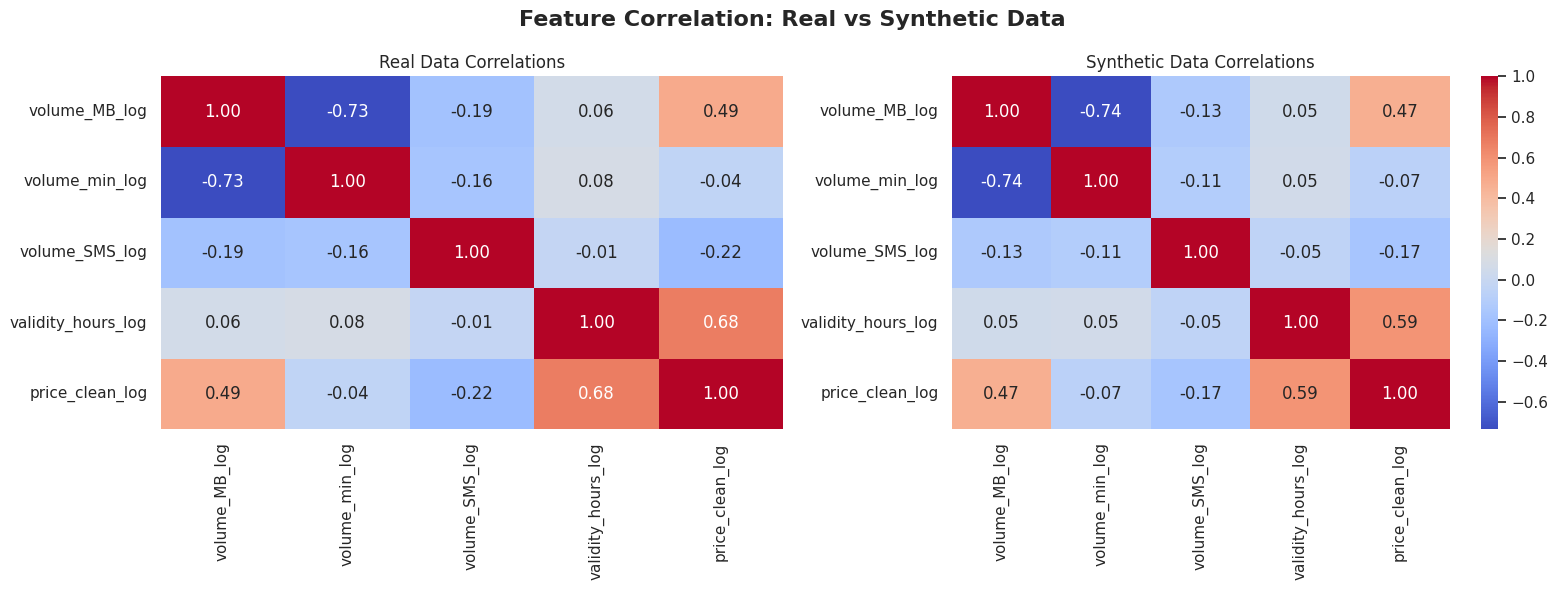

Generating Plot 3: PCA 2D Projection...


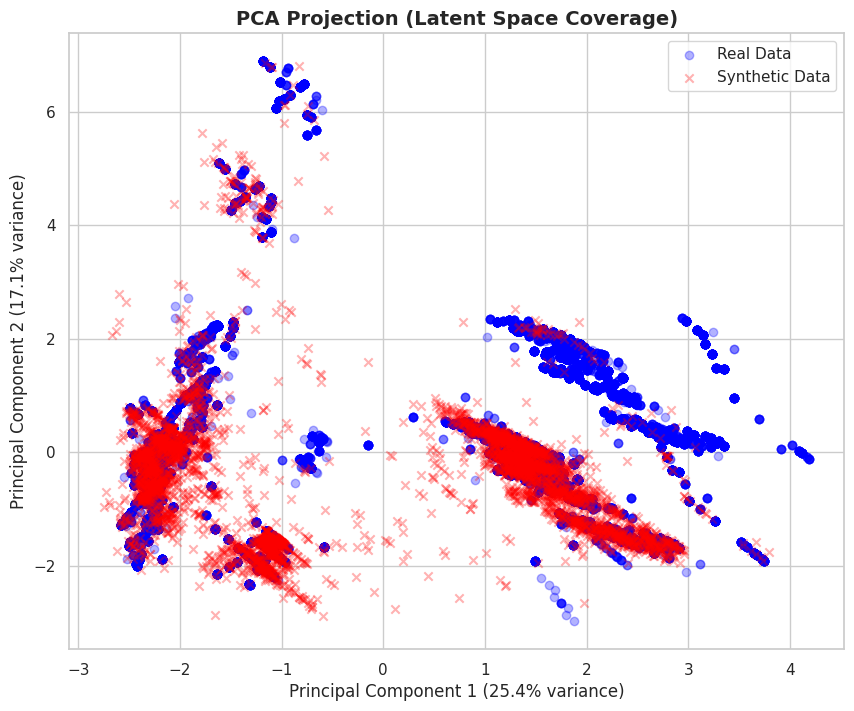

Generating Plot 4: Quality Scores per Column...


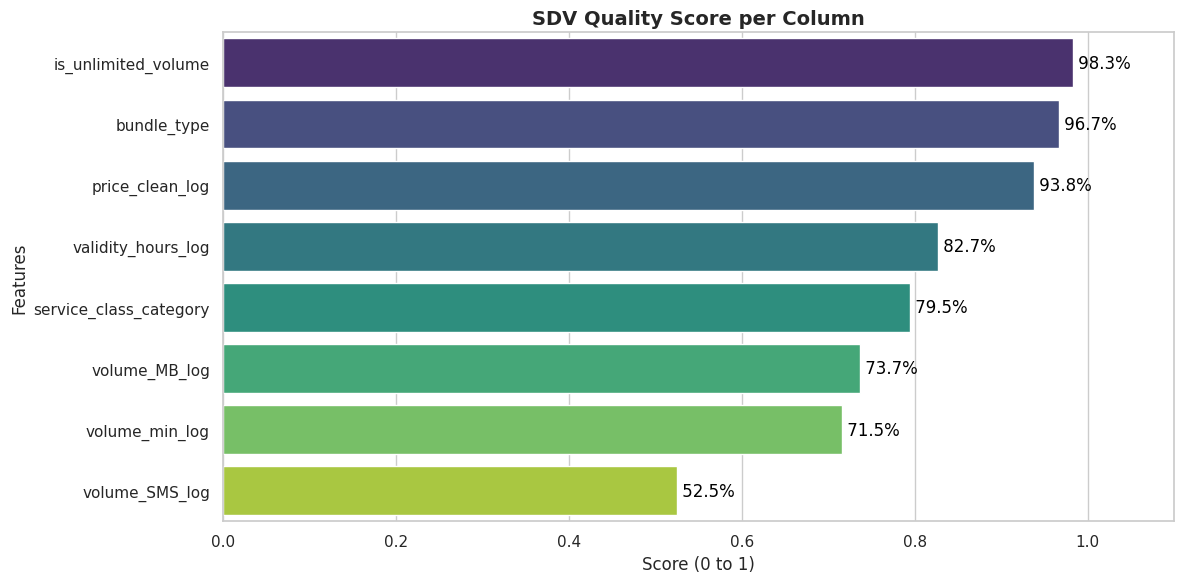

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def generate_thesis_visualizations(real_raw, synth_raw, synthesizer, report):

    sns.set_theme(style="whitegrid")



    print("Generating Plot 1: Histogram Overlay (Volume & Minutes)...")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('Distribution Overlays (Real vs Synthetic)', fontsize=16, fontweight='bold')

    columns_to_plot = ['volume_MB_log', 'volume_min_log']
    titles = ['Data Volume (Log Space)', 'Voice Minutes (Log Space)']

    for i, col in enumerate(columns_to_plot):
        sns.histplot(real_raw[col], color='blue', label='Real Data', kde=True, stat="density", bins=50, alpha=0.4, ax=axes[i])
        sns.histplot(synth_raw[col], color='red', label='Synthetic Data', kde=True, stat="density", bins=50, alpha=0.4, ax=axes[i])
        axes[i].set_title(titles[i])
        axes[i].legend()

    plt.tight_layout()
    plt.show()


    print("Generating Plot 2: Correlation Heatmaps...")
   
    num_cols = real_raw.select_dtypes(include=[np.number]).columns

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Feature Correlation: Real vs Synthetic Data', fontsize=16, fontweight='bold')

  
    sns.heatmap(real_raw[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0], cbar=False)
    axes[0].set_title('Real Data Correlations')

    
    sns.heatmap(synth_raw[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
    axes[1].set_title('Synthetic Data Correlations')

    plt.tight_layout()
    plt.show()


    print("Generating Plot 3: PCA 2D Projection...")
    
    real_encoded = pd.get_dummies(real_raw).astype(float)
    synth_encoded = pd.get_dummies(synth_raw).astype(float)

    
    synth_encoded = synth_encoded.reindex(columns=real_encoded.columns, fill_value=0)

  
    combined_data = pd.concat([real_encoded, synth_encoded], axis=0)
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(combined_data)

    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(scaled_data)

   
    n_real = len(real_encoded)
    pca_real = pca_result[:n_real]
    pca_synth = pca_result[n_real:]

    plt.figure(figsize=(10, 8))
    plt.scatter(pca_real[:, 0], pca_real[:, 1], c='blue', alpha=0.3, label='Real Data', marker='o')
    plt.scatter(pca_synth[:, 0], pca_synth[:, 1], c='red', alpha=0.3, label='Synthetic Data', marker='x')
    plt.title('PCA Projection (Latent Space Coverage)', fontsize=14, fontweight='bold')
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.legend()
    plt.show()


    print("Generating Plot 4: Quality Scores per Column...")
    column_details = report.get_details(property_name='Column Shapes')
    column_details = column_details.sort_values(by='Score', ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=column_details, x='Score', y='Column', palette='viridis')

    
    for index, value in enumerate(column_details['Score']):
        plt.text(value, index, f' {value:.1%}', color='black', va="center")

    plt.title('SDV Quality Score per Column', fontsize=14, fontweight='bold')
    plt.xlabel('Score (0 to 1)')
    plt.ylabel('Features')
    plt.xlim(0, 1.1)
    plt.tight_layout()
    plt.show()


generate_thesis_visualizations(df_train, synthetic_raw, synthesizer, final_report)

In [36]:
train_data.describe()

,volume_MB_log,volume_min_log,volume_SMS_log,validity_hours_log,price_clean_log
count,29973.000000,29973.000000,29973.000000,29973.000000,29973.000000
mean,3.899461,1.523059,0.200458,4.793776,6.912622
std,4.246039,1.916601,0.976938,1.355592,1.589039
min,0.000000,0.000000,0.000000,1.098612,2.397895
25%,0.000000,0.000000,0.000000,3.218876,5.860786
50%,0.000000,0.000000,0.000000,4.795791,6.580639
75%,7.337588,2.772589,0.000000,6.580639,7.832411
max,13.996232,7.280008,6.957497,9.064274,14.246644


In [37]:
synthetic_raw.describe()

,volume_MB_log,volume_min_log,volume_SMS_log,validity_hours_log,price_clean_log
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,3.684425,1.491263,0.126217,4.935881,6.879744
std,4.118632,1.783964,0.793705,1.379678,1.586640
min,0.000000,0.000000,0.000000,3.196827,2.613396
25%,0.000086,0.000000,0.000000,3.219739,5.974123
50%,0.004071,0.002540,0.000012,5.129159,6.504464
75%,7.087893,2.779771,0.000188,6.580051,7.744577
max,13.996232,7.280008,6.957497,6.587596,12.464962


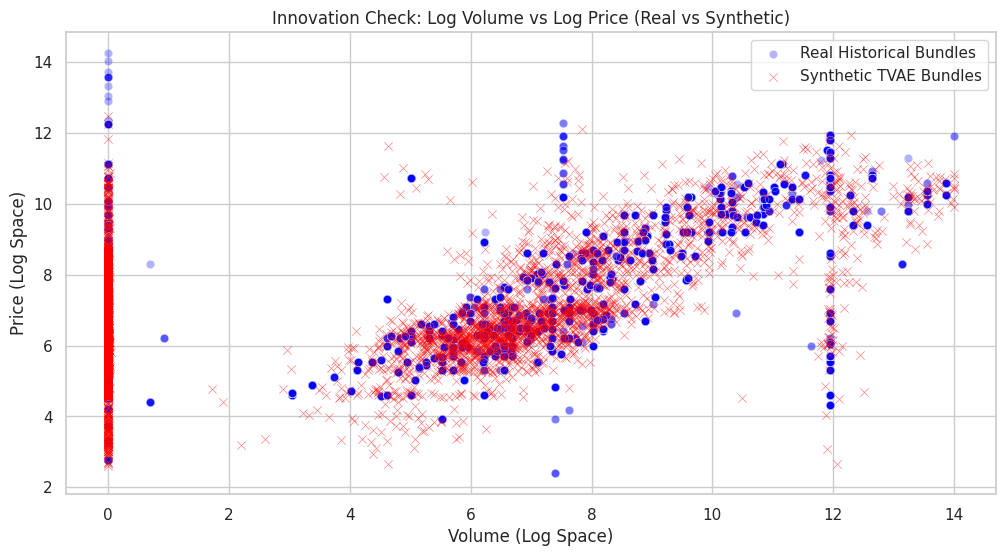

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))


sns.scatterplot(
    data=df_train,
    x='volume_MB_log', y='price_clean_log',
    color='blue', alpha=0.3, label='Real Historical Bundles'
)


sns.scatterplot(
    data=synthetic_raw,
    x='volume_MB_log', y='price_clean_log',
    color='red', alpha=0.5, marker='x', label='Synthetic TVAE Bundles'
)

plt.title('Innovation Check: Log Volume vs Log Price (Real vs Synthetic)')
plt.xlabel('Volume (Log Space)')
plt.ylabel('Price (Log Space)')
plt.legend()
plt.show()


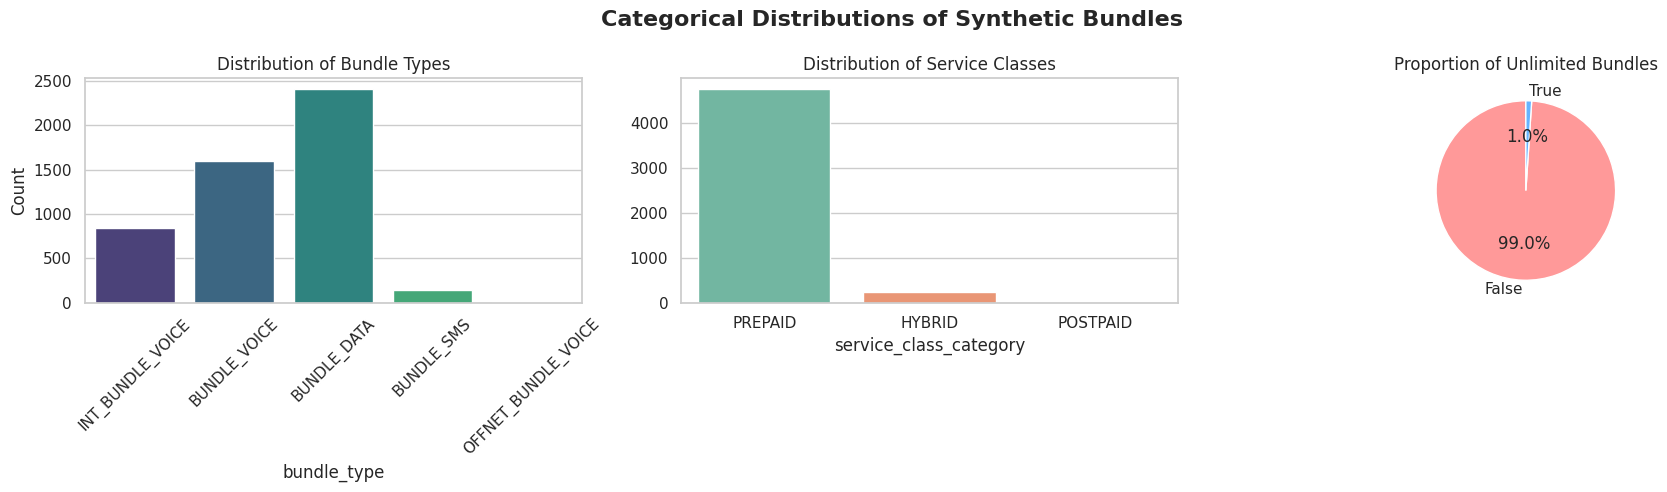

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Categorical Distributions of Synthetic Bundles', fontsize=16, fontweight='bold')


sns.countplot(data=synthetic_bundles_ready, x='bundle_type', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Bundle Types')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Count')


sns.countplot(data=synthetic_bundles_ready, x='service_class_category', ax=axes[1], palette='Set2')
axes[1].set_title('Distribution of Service Classes')
axes[1].set_ylabel('')


synthetic_bundles_ready['is_unlimited_volume'].value_counts().plot.pie(
    ax=axes[2], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff']
)
axes[2].set_title('Proportion of Unlimited Bundles')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

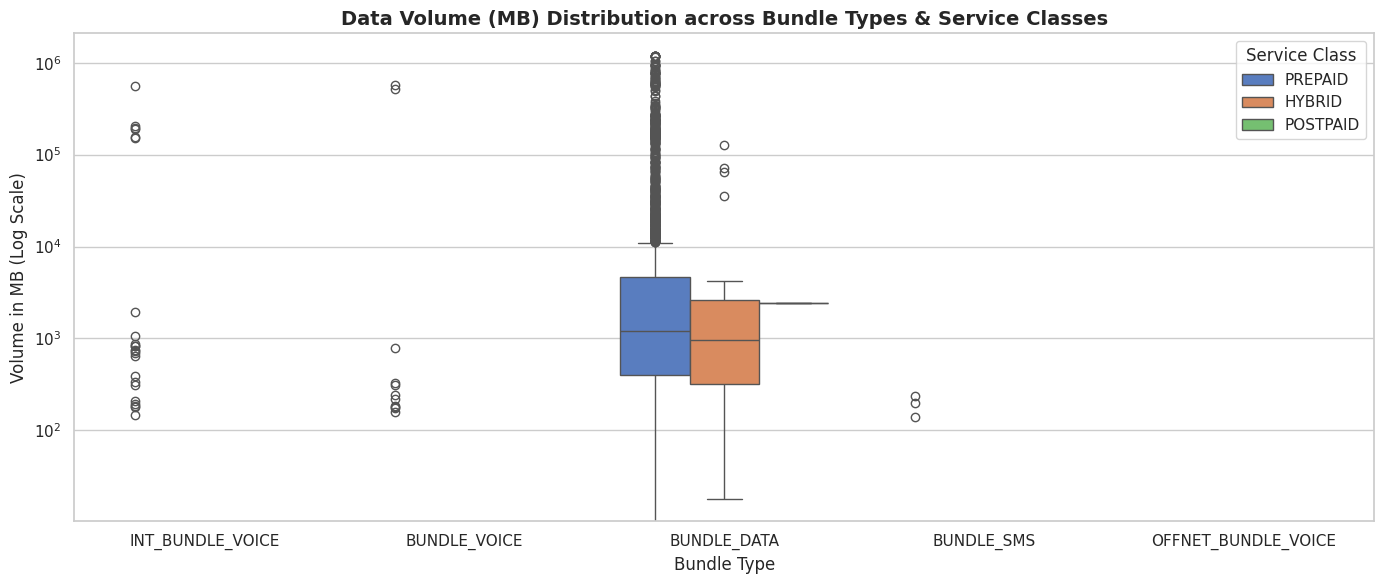

--- Summary Statistics for Synthetic Volumes (MB) by Bundle Type ---


,count,mean,std,min,25%,50%,75%,max
bundle_type,,,,,,,,
BUNDLE_DATA,2409.0,33367.00,128511.77,-1.0,398.0,1190.0,4486.0,1198080.0
BUNDLE_SMS,144.0,3.99,28.04,0.0,0.0,0.0,0.0,237.0
BUNDLE_VOICE,1598.0,689.87,19470.31,-1.0,0.0,0.0,0.0,576172.0
INT_BUNDLE_VOICE,840.0,1752.27,23892.73,-1.0,0.0,0.0,0.0,563832.0
OFFNET_BUNDLE_VOICE,9.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0


In [ ]:
plt.figure(figsize=(14, 6))


sns.boxplot(data=synthetic_bundles_ready,
            x='bundle_type',
            y='volume_MB',
            hue='service_class_category',
            palette='muted')


plt.yscale('log')
plt.title('Data Volume (MB) Distribution across Bundle Types & Service Classes', fontsize=14, fontweight='bold')
plt.ylabel('Volume in MB (Log Scale)')
plt.xlabel('Bundle Type')
plt.legend(title='Service Class')

plt.tight_layout()
plt.show()


print("--- Summary Statistics for Synthetic Volumes (MB) by Bundle Type ---")
display(synthetic_bundles_ready.groupby('bundle_type')['volume_MB'].describe().round(2))